# ***Multi-Label Toxic Comment Classification***

# Section 0 — Environment & Global Imports

Sets reproducibility, device, plotting style, and the six target labels.
Everything downstream depends only on this cell.

In [1]:
import os, re, html, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
MODEL_COLORS = {"RNN": "steelblue", "LSTM": "darkorange"}

Device: cuda


# Section 1 — Data Profiling

Understand schema, balance, text length, and label co-occurrence before
touching any model.

## 1.1 Load the Dataset

In [2]:
TRAIN_PATH = "train.csv"
train_df = pd.read_csv(TRAIN_PATH)
print("Train shape:", train_df.shape)

Train shape: (159571, 8)


In [3]:
train_df["label_combo"] = train_df[LABEL_COLS].astype(str).agg("".join, axis=1)
combo_counts = train_df["label_combo"].value_counts()
print(f"Distinct label combinations: {len(combo_counts)}")
print(combo_counts.head(15))

# warning if any combo has < 100 samples — those will be under-represented in val/calib/test
rare_combos = combo_counts[combo_counts < 100]
print(f"\nRare combinations (<100 rows): {len(rare_combos)}")

Distinct label combinations: 41
label_combo
000000    143346
100000      5666
101010      3800
101000      1758
100010      1215
111010       989
101011       618
001000       317
000010       301
111011       265
001010       181
111000       158
100001       136
100011       134
101110       131
Name: count, dtype: int64

Rare combinations (<100 rows): 25


Why: with 6 binary labels there are up to 64 combos. train_test_split(..., stratify=strat) where strat is a scalar ordinal only preserves the outer joint distribution, not each label individually. iterstrat handles this properly.

## 1.2 — Schema & Missingness

In [4]:
train_df.info()
print("-" * 60)
print("Missing values:")
print(train_df.isnull().sum())
print("Duplicate comment_texts:", train_df.duplicated(subset=["comment_text"]).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
 8   label_combo    159571 non-null  object
dtypes: int64(6), object(3)
memory usage: 11.0+ MB
------------------------------------------------------------
Missing values:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
label_combo      0
dtype: int64
Duplicate comment_texts: 0


## 1.3 — Head Inspection

In [5]:
pd.set_option("display.max_colwidth", 200)
display(train_df.head())

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,label_combo
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",0,0,0,0,0,0,000000
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0,000000
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",0,0,0,0,0,0,000000
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",0,0,0,0,0,0,000000
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0,000000


## 1.4 — Sanity: severe/rare label dependencies
Check how many positives exist for each label **without** toxic=1.
This validates the hierarchical structure used later for gating.

In [6]:
for col in LABEL_COLS[1:]:
    n = int((train_df[col].astype(bool) & ~train_df["toxic"].astype(bool)).sum())
    print(f"{col:15s} positives without toxic=1 : {n}")

severe_toxic    positives without toxic=1 : 0
obscene         positives without toxic=1 : 523
threat          positives without toxic=1 : 29
insult          positives without toxic=1 : 533
identity_hate   positives without toxic=1 : 103


## 1.5 — Class Imbalance
Absolute counts (log-scale) and percentages. Severe imbalance is why
we use focal loss + per-class thresholds downstream.

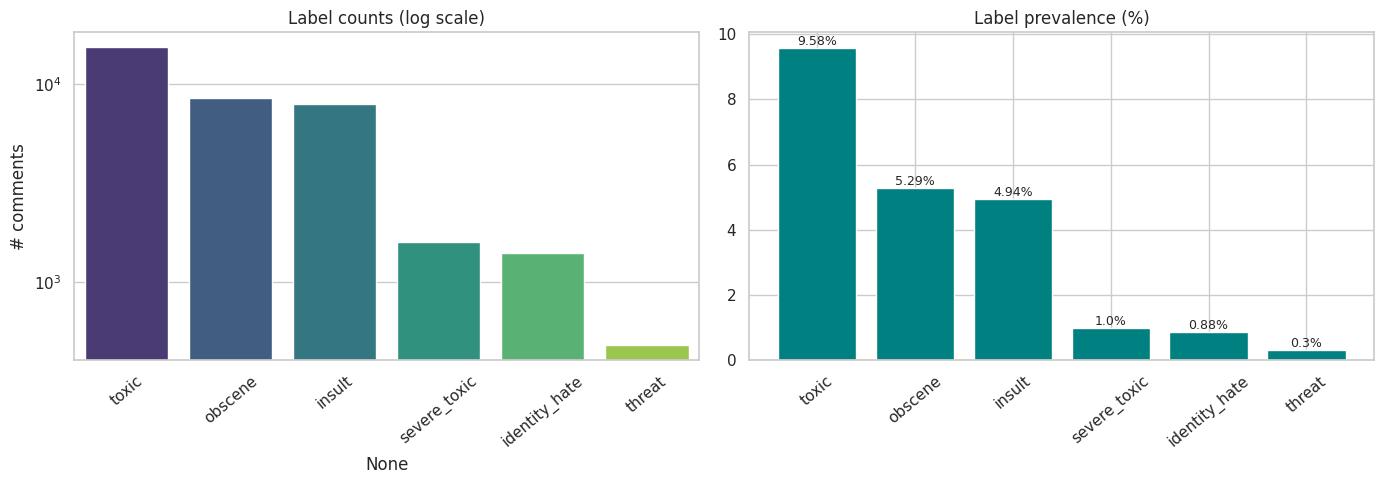

In [7]:
counts = train_df[LABEL_COLS].sum().sort_values(ascending=False)
pct    = (counts / len(train_df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette="viridis")
axes[0].set_yscale("log")
axes[0].set_title("Label counts (log scale)")
axes[0].set_ylabel("# comments"); axes[0].tick_params(axis="x", rotation=40)

axes[1].bar(counts.index, pct.values, color="teal")
for i, v in enumerate(pct.values):
    axes[1].text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Label prevalence (%)")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout(); plt.show()

## 1.6 — Text Length Distribution
Informs MAX_LEN for the sequence models.

          word_count    char_length
count  159571.000000  159571.000000
mean       67.273527     394.073221
std        99.230702     590.720282
min         1.000000       6.000000
25%        17.000000      96.000000
50%        36.000000     205.000000
75%        75.000000     435.000000
max      1411.000000    5000.000000


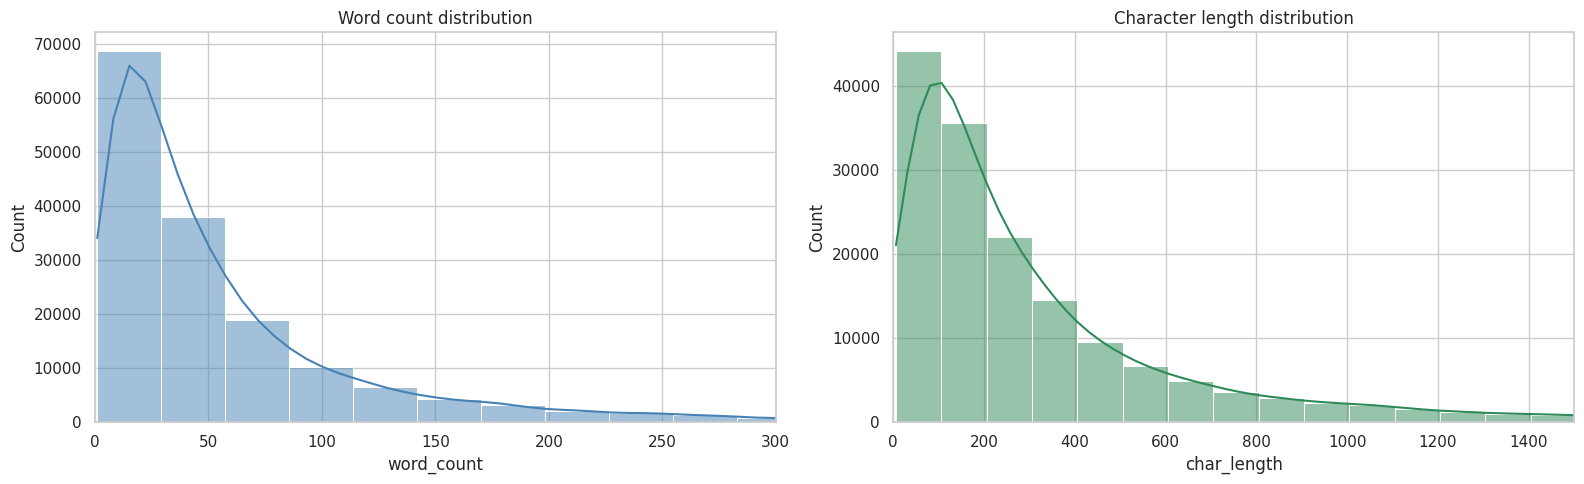

In [8]:
train_df["word_count"] = train_df["comment_text"].str.split().str.len()
train_df["char_length"] = train_df["comment_text"].str.len()

print(train_df[["word_count", "char_length"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(train_df["word_count"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_xlim(0, 300); axes[0].set_title("Word count distribution")

sns.histplot(train_df["char_length"], bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].set_xlim(0, 1500); axes[1].set_title("Character length distribution")

plt.tight_layout(); plt.show()

## 1.7 — Raw Text Sampling

In [9]:
for i, t in enumerate(train_df["comment_text"].sample(8, random_state=SEED).values, 1):
    print(f"--- Sample {i} ---\n{t}\n")

--- Sample 1 ---
Geez, are you forgetful!  We've already discussed why Marx  was  not an anarchist, i.e. he wanted to use a State to mold his 'socialist man.'  Ergo, he is a statist - the opposite of an  anarchist.  I know a guy who says that, when he gets old and his teeth fall out, he'll quit eating meat.  Would you call him a vegetarian?

--- Sample 2 ---
Carioca RFA 

Thanks for your support on my request for adminship.

The final outcome was (31/4/1), so I am now an administrator. If you have any comments or concerns on my actions as an administrator, please let me know. Thank you!

--- Sample 3 ---
"

 Birthday 

No worries, It's what I do ;)Enjoy ur day|talk|e "

--- Sample 4 ---
Pseudoscience category? 

I'm assuming that this article is in the pseudoscience category because of its association with creationism.  However, there are modern, scientifically-accepted variants of catastrophism that have nothing to do with creationism — and they're even mentioned in the article!  I th

## 1.8 — Label Co-occurrence & Overlap
The co-occurrence matrix is the empirical justification for
hierarchical gating (toxic-gated) applied later.

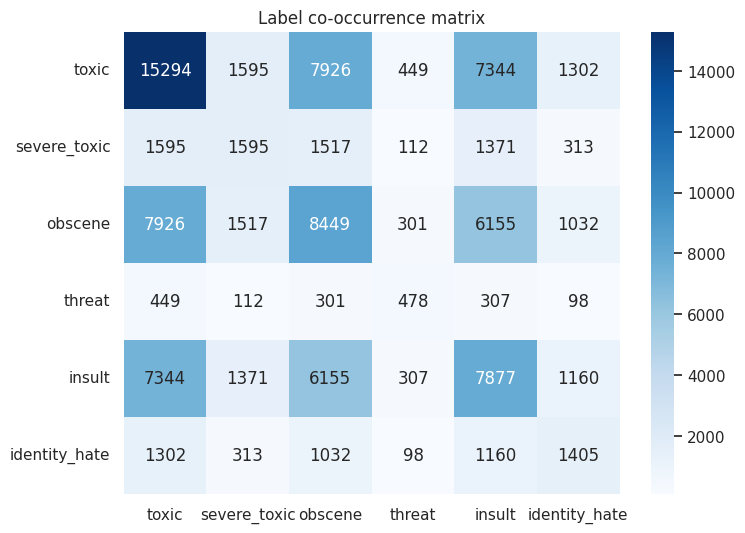


Labels per comment:
num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64
Label prevalence vs conditional on toxic=1:
  severe_toxic     P=0.0100   P(|toxic)=0.1043   ratio=10.4x
  obscene          P=0.0529   P(|toxic)=0.5182   ratio=9.8x
  threat           P=0.0030   P(|toxic)=0.0294   ratio=9.8x
  insult           P=0.0494   P(|toxic)=0.4802   ratio=9.7x
  identity_hate    P=0.0088   P(|toxic)=0.0851   ratio=9.7x


In [10]:
cooc = train_df[LABEL_COLS].T.dot(train_df[LABEL_COLS])
plt.figure(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues")
plt.title("Label co-occurrence matrix")
plt.show()

train_df["num_labels"] = train_df[LABEL_COLS].sum(axis=1)
print("\nLabels per comment:")
print(train_df["num_labels"].value_counts().sort_index())

print("Label prevalence vs conditional on toxic=1:")
for col in LABEL_COLS[1:]:
    p_global = train_df[col].mean()
    p_cond   = train_df.loc[train_df["toxic"]==1, col].mean()
    print(f"  {col:15s}  P={p_global:.4f}   P(|toxic)={p_cond:.4f}   ratio={p_cond/p_global:.1f}x")

## 1.9 — Length vs Label
Do toxic comments tend to be longer or shorter? Quick read via violin plots.

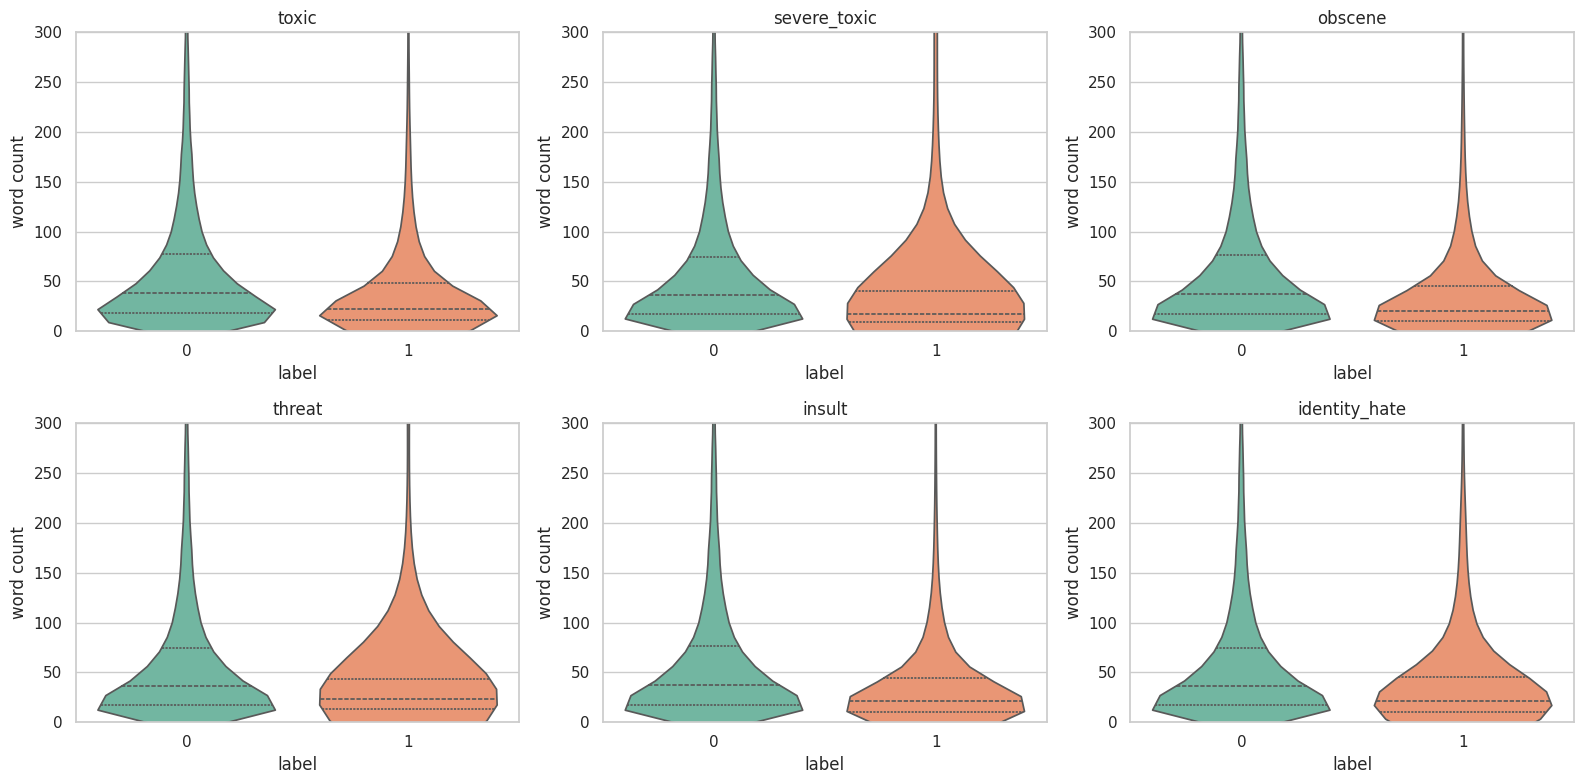

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, LABEL_COLS):
    sns.violinplot(x=train_df[col], y=train_df["word_count"],
                   ax=ax, palette="Set2", inner="quartile")
    ax.set_title(col); ax.set_xlabel("label"); ax.set_ylabel("word count")
    ax.set_ylim(0, 300)
plt.tight_layout(); plt.show()

## 1.10 — Top Trigger Tokens per Class
Visual alternative to the raw print: shows why rare classes (threat,
identity_hate) are hard — signal is dominated by a few tokens.

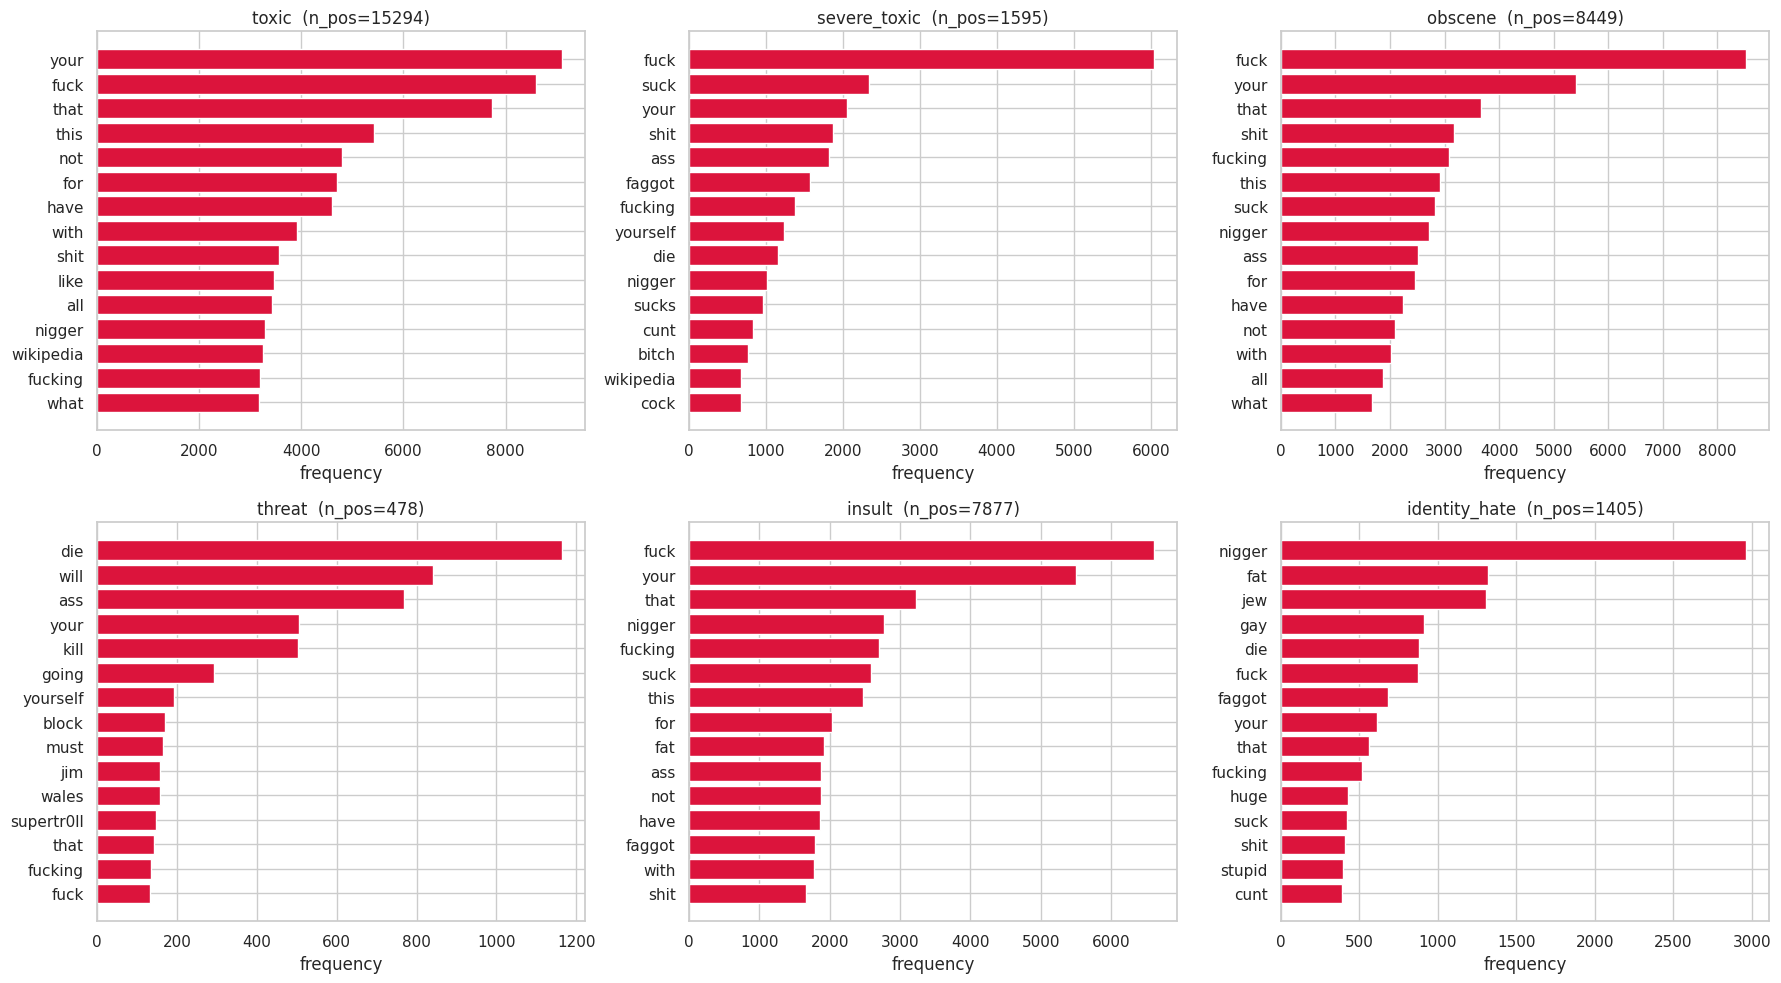

In [12]:
STOP = set("the a an and or of to in is are was were be been i you he she it we they".split())

def top_tokens(texts, k=15):
    c = Counter()
    for t in texts:
        for w in str(t).lower().split():
            w = w.strip(".,!?;:()[]{}\"'")
            if w and w not in STOP and len(w) > 2:
                c[w] += 1
    return c.most_common(k)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, LABEL_COLS):
    pos = train_df.loc[train_df[col] == 1, "comment_text"]
    toks, freqs = zip(*top_tokens(pos, k=15))
    ax.barh(list(toks)[::-1], list(freqs)[::-1], color="crimson")
    ax.set_title(f"{col}  (n_pos={len(pos)})")
    ax.set_xlabel("frequency")
plt.tight_layout(); plt.show()

# Section 2 — Preprocessing

Cleaning -> vocabulary -> class weights -> DataLoaders -> GloVe.

## 2.1 — Text Cleaning
Order matters: **deobfuscate before stripping punctuation** so that
`f*ck` and `f.u.c.k` collapse into the canonical `fuck`.

In [13]:
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.stem import WordNetLemmatizer
_lemmatizer = WordNetLemmatizer()

_LB = r"(?<![a-zA-Z])"

RE_PATTERNS = {
    "fuck":    [rf"{_LB}f\*+c?k?",rf"{_LB}f[\W_]*u[\W_]*c[\W_]*k",rf"{_LB}fuk\w*", rf"{_LB}fck\w*", rf"{_LB}wtf"],
    "shit":    [rf"{_LB}s[\W_]*h[\W_]*i[\W_]*t", rf"{_LB}\$hit"],
    "bitch":   [rf"{_LB}b[\W_]*i[\W_]*t[\W_]*c[\W_]*h", rf"{_LB}b!tch", rf"{_LB}biatch"],
    "asshole": [rf"{_LB}a[\W_]*s+[\W_]*h[\W_]*o+[\W_]*l+[\W_]*e"],
    "ass":     [rf"{_LB}ass(?![a-zA-Z])", rf"{_LB}@\$\$"],
    "dick":    [rf"{_LB}d[\W_]*i[\W_]*c[\W_]*k"],
    "cunt":    [rf"{_LB}c[\W_]*u[\W_]*n[\W_]*t"],
    "nigger":  [rf"{_LB}n[\W_]*i[\W_]*g+[\W_]*[ae]+[\W_]*r", rf"{_LB}n3gr"],
    "faggot":  [rf"{_LB}f[\W_]*a[\W_]*g+[\W_]*[o0]+[\W_]*t", rf"{_LB}fagot"],
    "retard":  [rf"{_LB}r[\W_]*e[\W_]*t[\W_]*a[\W_]*r[\W_]*d"],
    "idiot":   [rf"{_LB}i[\W_]*d[\W_]*i[\W_]*o[\W_]*t"],
    "dumb":    [rf"{_LB}d[\W_]*u[\W_]*m[\W_]*b"],
    "rape":    [rf"{_LB}r[\W_]*a[\W_]*p[\W_]*e"],
    "kill":    [rf"{_LB}k[\W_]*i[\W_]*l[\W_]*l"],
    "hate":    [rf"{_LB}h[\W_]*a[\W_]*t[\W_]*e"],
    "hitler":  [rf"{_LB}hitler"],
}

# Pre-compile
_RE_COMPILED = {c: [re.compile(p, re.IGNORECASE) for p in pats] for c, pats in RE_PATTERNS.items()}

_url_re  = re.compile(r"https?://\S+|www\.\S+")
_ip_re   = re.compile(r"\b\d{1,3}(?:\.\d{1,3}){3}\b")
_html_re = re.compile(r"<[^>]+>")
_wiki1   = re.compile(r"\[\[([^|\]]+)\|([^\]]+)\]\]")
_wiki2   = re.compile(r"\[\[([^\]]+)\]\]")
_tmpl    = re.compile(r"\{\{.*?\}\}")
_repeat  = re.compile(r"(.)\1{2,}")

def _deobfuscate(text: str) -> str:
    for canon, pats in _RE_COMPILED.items():
        for p in pats:
            text = p.sub(f" {canon} ", text)
    return text

def _lemmatize(text: str) -> str:
    return " ".join(
        _lemmatizer.lemmatize(
            _lemmatizer.lemmatize(_lemmatizer.lemmatize(w, pos="n"), pos="v"), pos="a")
        for w in text.split()
    )

def clean_text(text: str, do_lemma: bool = True) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = _html_re.sub(" ", text)
    text = _wiki1.sub(r"\2", text)
    text = _wiki2.sub(r"\1", text)
    text = _tmpl.sub(" ", text)
    text = re.sub(r"'{2,}", "", text)
    text = re.sub(r"~{3,}", " ", text)
    text = _url_re.sub(" <url> ", text)
    text = _ip_re.sub(" <ip> ", text)
    text = text.lower()
    text = _deobfuscate(text)
    text = re.sub(r"[^a-z0-9\s'.,!?<>]", " ", text)
    text = _repeat.sub(r"\1\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return _lemmatize(text) if do_lemma else text

def tokenize(text: str):
    return re.findall(r"<url>|<ip>|[a-z]+(?:['\-][a-z]+)*|\d+|[!?.,;:]", text)

# --- Regression test: Scunthorpe / grape / skill / chateau must NOT get corrupted
_sanity = ["scunthorpe", "grape", "skill", "chateau", "classy assistant",
           "f u c k", "f*ck", "you are an asshole"]
for s in _sanity:
    print(f"{s:25s} -> {clean_text(s)}")


train_df["clean_text"] = train_df["comment_text"].apply(clean_text)
print("Empty after cleaning:", (train_df["clean_text"].str.strip() == "").sum())

scunthorpe                -> scunthorpe
grape                     -> grape
skill                     -> skill
chateau                   -> chateau
classy assistant          -> classy assistant
f u c k                   -> fuck
f*ck                      -> fuck
you are an asshole        -> you be an asshole
Empty after cleaning: 22


## 2.2 — Split, Vocabulary, Class Weights, DataLoaders

- Stratified split on the *rarest* label (threat) to preserve it in val.
- Rare-class oversampling on the training split only.
- pos_weight capped at 10 to avoid the extreme ratios dominating the loss.

In [14]:
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    HAS_ITERSTRAT = True
except ImportError:
    HAS_ITERSTRAT = False

MAX_LEN    = 220
MIN_FREQ   = 2
BATCH_SIZE = 64
EMBED_DIM  = 300

def _combo_strat(y: np.ndarray) -> np.ndarray:
    """Deterministic scalar signal from 6-bit label combo (fallback stratifier)."""
    weights = (1 << np.arange(y.shape[1]))
    return (y.astype(int) * weights).sum(axis=1)

def multilabel_split_idx(y: np.ndarray, test_size: float, seed: int):
    """Return (keep_idx, split_idx) with iterative multilabel stratification if possible."""
    n = len(y)
    if HAS_ITERSTRAT:
        msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        keep, split = next(msss.split(np.zeros((n, 1)), y))
        return keep, split
    strat = _combo_strat(y)
    # fallback: if a combo is too rare for sklearn's stratify, collapse it
    counts = np.bincount(strat)
    rare = np.where(counts < 2)[0]
    strat = np.where(np.isin(strat, rare), -1, strat)
    keep, split = train_test_split(np.arange(n), test_size=test_size,
                                   random_state=seed, stratify=strat)
    return np.asarray(keep), np.asarray(split)

X_text = train_df["clean_text"].values
y      = train_df[LABEL_COLS].values.astype(np.float32)

# 1) hold out test (10%)
idx_rest, idx_test = multilabel_split_idx(y, 0.10, SEED)
# 2) hold out calib (10% of remaining -> ~10% overall)
idx_rest2, idx_calib = multilabel_split_idx(y[idx_rest], 0.10 / 0.90, SEED + 1)
idx_rest2 = idx_rest[idx_rest2]
idx_calib = idx_rest[idx_calib]
# 3) hold out val (10% of remaining -> ~10% overall)
idx_train, idx_val = multilabel_split_idx(y[idx_rest2], 0.10 / 0.80, SEED + 2)
idx_train = idx_rest2[idx_train]
idx_val   = idx_rest2[idx_val]

X_train, y_train = X_text[idx_train], y[idx_train]
X_val,   y_val   = X_text[idx_val],   y[idx_val]
X_calib, y_calib = X_text[idx_calib], y[idx_calib]
X_test,  y_test  = X_text[idx_test],  y[idx_test]

print(f"train  : {len(X_train):>6d}  pos/label: {y_train.sum(0).astype(int)}")
print(f"val    : {len(X_val):>6d}  pos/label: {y_val.sum(0).astype(int)}")
print(f"calib  : {len(X_calib):>6d}  pos/label: {y_calib.sum(0).astype(int)}")
print(f"test   : {len(X_test):>6d}  pos/label: {y_test.sum(0).astype(int)}")

# --- Vocabulary (built ONLY from train) ---
class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {"<pad>": 0, "<unk>": 1}
        self.vocab_size = 2
    def build_vocab(self, texts):
        c = Counter()
        for t in texts: c.update(tokenize(t))
        for w, n in c.items():
            if n >= self.min_freq:
                self.word2idx[w] = self.vocab_size
                self.vocab_size += 1
        print("Vocab size:", self.vocab_size)
    def numericalize(self, text):
        return [self.word2idx.get(t, 1) for t in tokenize(text)]

vocab = Vocabulary(MIN_FREQ); vocab.build_vocab(X_train)

train  : 111698  pos/label: [10703  1119  5913   339  5513   980]
val    :  15957  pos/label: [1530  158  845   47  788  142]
calib  :  15958  pos/label: [1530  159  845   46  788  141]
test   :  15958  pos/label: [1531  159  846   46  788  142]
Vocab size: 64940


In [15]:
# --- Rare-class oversampling on TRAIN only ---
rare_cols = ["threat", "identity_hate", "severe_toxic"]
rare_idx  = [LABEL_COLS.index(c) for c in rare_cols]
rare_mask = y_train[:, rare_idx].sum(1) > 0
X_rare, y_rare = X_train[rare_mask], y_train[rare_mask]

# 2x duplicates of rare rows
X_train_os = np.concatenate([X_train, X_rare, X_rare])
y_train_os = np.concatenate([y_train, y_rare, y_rare])
print("Train size after oversample:", len(X_train_os))

# compute pos_weight AFTER oversampling ---
pos = y_train_os.sum(0)
neg = len(y_train_os) - pos
pos_weights = np.clip(neg / (pos + 1e-6), 1.0, 10.0)
pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32)
for c, w in zip(LABEL_COLS, pos_weights):
    print(f"  {c:15s} -> pos_weight = {w:.3f}")

# --- Datasets / loaders ---
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels=None, vocab=None, max_len=MAX_LEN):
        self.texts, self.labels, self.vocab, self.max_len = texts, labels, vocab, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        toks = self.vocab.numericalize(self.texts[i])[:self.max_len] or [1]
        length = len(toks)
        if self.labels is None:
            return torch.tensor(toks), torch.tensor(length)
        return torch.tensor(toks), torch.tensor(self.labels[i], dtype=torch.float32), torch.tensor(length)

def collate_train(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    xs, ys, ls = zip(*batch)
    return pad_sequence(xs, batch_first=True, padding_value=0), torch.stack(ys), torch.stack(ls)

train_loader = DataLoader(ToxicityDataset(X_train_os, y_train_os, vocab),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=collate_train)
val_loader   = DataLoader(ToxicityDataset(X_val, y_val, vocab),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate_train)
calib_loader = DataLoader(ToxicityDataset(X_calib, y_calib, vocab),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate_train)
test_loader  = DataLoader(ToxicityDataset(X_test, y_test, vocab),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=collate_train)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | "
      f"Calib: {len(calib_loader)} | Test: {len(test_loader)}")

Train size after oversample: 115884
  toxic           -> pos_weight = 6.884
  severe_toxic    -> pos_weight = 10.000
  obscene         -> pos_weight = 10.000
  threat          -> pos_weight = 10.000
  insult          -> pos_weight = 10.000
  identity_hate   -> pos_weight = 10.000
Train batches: 1811 | Val: 250 | Calib: 250 | Test: 250


## 2.3 — GloVe Embedding Matrix (300d, 6B)
Coverage report tells us what fraction of the vocabulary gets pretrained vectors.

In [16]:
GLOVE_DIR  = "glove"
GLOVE_ZIP  = os.path.join(GLOVE_DIR, "glove.6B.zip")
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.300d.txt")

if not os.path.exists(GLOVE_FILE):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    !wget -q --show-progress -O {GLOVE_ZIP} https://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q -o {GLOVE_ZIP} glove.6B.300d.txt -d {GLOVE_DIR}
    !rm {GLOVE_ZIP}

def build_embedding_matrix(vocab, embed_dim=300, glove_path=GLOVE_FILE):
    embeddings = np.random.normal(0, 0.1, (vocab.vocab_size, embed_dim)).astype(np.float32)
    embeddings[0] = 0.0
    found = 0
    with open(glove_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.rstrip().rsplit(" ", embed_dim)
            word = parts[0]
            if word in vocab.word2idx:
                vec = np.asarray(parts[1:], dtype=np.float32)
                if vec.shape[0] == embed_dim:
                    embeddings[vocab.word2idx[word]] = vec
                    found += 1
    print(f"GloVe coverage: {found}/{vocab.vocab_size} = {100*found/vocab.vocab_size:.2f}%")
    return torch.tensor(embeddings)

embedding_matrix = build_embedding_matrix(vocab, embed_dim=EMBED_DIM)
print("Embedding matrix shape:", tuple(embedding_matrix.shape))

glove/glove.6B.zip  100%[===================>] 822.24M  1.66MB/s    in 5m 23s  
GloVe coverage: 48708/64940 = 75.00%
Embedding matrix shape: (64940, 300)


# Section 3 — Shared Components

Everything model-agnostic: config, loss, threshold tuning, calibration,
gating, generic training loop, and the evaluation report.

In [17]:
# Training configuration
HIDDEN_DIM    = 160
NUM_LAYERS    = 2
OUTPUT_DIM    = 6
DROPOUT       = 0.35

BASE_LR       = 2e-4
EMBED_LR      = 2e-5
WEIGHT_DECAY  = 5e-4
EPOCHS        = 10
PATIENCE      = 3
MAX_GRAD_NORM = 1.0
FREEZE_EPOCHS = 1

FOCAL_GAMMA   = 2.0
FOCAL_ALPHA   = 0.25

pos_weight_tensor = pos_weight_tensor.to(device)
print("pos_weight:", pos_weight_tensor)

pos_weight: tensor([ 6.8838, 10.0000, 10.0000, 10.0000, 10.0000, 10.0000], device='cuda:0')


## 3.2 — Focal Loss
BCE + focal modulation; class-weighted via `pos_weight`.

In [18]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha, self.gamma, self.pos_weight = alpha, gamma, pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction="none")
        p   = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        a_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (a_t * bce * ((1 - p_t) ** self.gamma)).mean()

## 3.3 — Threshold Tuning
- tune_thresholds_macro: coordinate ascent to maximise macro-F1 (used downstream)

In [19]:
def find_best_thresholds(y_true, y_probs):
    thresholds, f1s = [], []
    for i in range(y_true.shape[1]):
        p, r, t = precision_recall_curve(y_true[:, i], y_probs[:, i])
        f1 = 2 * p * r / (p + r + 1e-12)
        idx = np.nanargmax(f1[:-1])
        thresholds.append(float(t[idx])); f1s.append(float(f1[idx]))
    return thresholds, f1s

def tune_thresholds_macro(y_true, y_probs, init_thresholds=None,
                          n_rounds=5, grid=np.linspace(0.05, 0.95, 19)):
    """
    Coordinate-ascent threshold tuning to maximise MACRO-F1.
    Grid is wider (0.05..0.95) since rare-class thresholds often sit high.
    """
    n_labels = y_true.shape[1]
    thr = np.array(init_thresholds if init_thresholds is not None
                   else [0.5] * n_labels, dtype=float)
    for _ in range(n_rounds):
        for i in range(n_labels):
            best_thr, best_score = thr[i], -1.0
            for t in grid:
                cand = thr.copy(); cand[i] = t
                pred = (y_probs >= cand[None, :]).astype(int)
                score = f1_score(y_true, pred, average="macro", zero_division=0)
                if score > best_score:
                    best_score, best_thr = score, t
            thr[i] = best_thr
    return thr.tolist()

## 3.4 — Calibration & Hierarchical Gating
- Platt scaling (per-class logistic regression fit on validation logits).
- Gating: if P(toxic) < t_toxic, zero out all other labels for that row.
  Justified by Section 1.4 (rare labels almost never appear without toxic).

In [20]:
def calibrate_probs(logits_fit, y_fit, logits_apply):
    """Platt scaling fit on a calibration set, applied to another set."""
    cal_apply = np.zeros_like(logits_apply, dtype=float)
    for i in range(y_fit.shape[1]):
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(logits_fit[:, [i]], y_fit[:, i])
        cal_apply[:, i] = lr.predict_proba(logits_apply[:, [i]])[:, 1]
    return cal_apply

def apply_hierarchical_gating(y_probs, t_toxic=0.35):
    y = y_probs.copy()
    toxic_idx = LABEL_COLS.index("toxic")
    other_idx = [i for i in range(y.shape[1]) if i != toxic_idx]
    low = y[:, toxic_idx] < t_toxic
    y[np.ix_(low, other_idx)] = 0.0
    return y

def tune_gating_threshold_macro(y_true, y_probs, thresholds,
                                grid=np.linspace(0.0, 0.6, 25)):
    """Pick t_toxic that maximises MACRO-F1 after gating."""
    best_t, best_score = 0.0, -1.0
    thr_arr = np.array(thresholds)
    for t in grid:
        gated = apply_hierarchical_gating(y_probs, t_toxic=t)
        pred  = (gated >= thr_arr[None, :]).astype(int)
        score = f1_score(y_true, pred, average="macro", zero_division=0)
        if score > best_score:
            best_score, best_t = score, t
    return best_t

## 3.5 — Generic Training Loop & Evaluation Report
Used unchanged by both RNN and LSTM pipelines.

In [21]:
def _forward_probs(model, loader, device):
    model.eval()
    L, P, Y = [], [], []
    with torch.no_grad():
        for xb, yb, lens in loader:
            xb, yb, lens = xb.to(device), yb.to(device), lens.to(device)
            logits = model(xb, lens)
            L.append(logits.cpu().numpy())
            P.append(torch.sigmoid(logits).cpu().numpy())
            Y.append(yb.cpu().numpy())
    return np.vstack(L), np.vstack(P), np.vstack(Y).astype(int)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs, patience, device, model_name="Model"):
    """
    Early stopping on UNTUNED validation macro-F1 (threshold 0.5).
    This avoids leaking threshold/calibration choices into model selection.
    """
    model.to(device)
    train_losses, val_losses, val_f1s = [], [], []
    best_f1, best_state = -1.0, None
    best_logits, best_probs, best_labels = None, None, None
    no_improve = 0

    for epoch in range(epochs):
        model.embedding.weight.requires_grad = (epoch >= FREEZE_EPOCHS)

        # --- train ---
        model.train()
        running = 0.0
        for xb, yb, lens in train_loader:
            xb, yb, lens = xb.to(device), yb.to(device), lens.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb, lens)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            running += loss.item()
        train_loss = running / len(train_loader)

        # --- val ---
        logits_arr, probs_arr, labels_arr = _forward_probs(model, val_loader, device)
        with torch.no_grad():
            vl = 0.0
            for xb, yb, lens in val_loader:
                xb, yb, lens = xb.to(device), yb.to(device), lens.to(device)
                vl += criterion(model(xb, lens), yb).item()
            val_loss = vl / len(val_loader)

        # UNTUNED macro-F1 @ 0.5  (no leakage)
        pred = (probs_arr >= 0.5).astype(int)
        monitor = f1_score(labels_arr, pred, average="macro", zero_division=0)

        train_losses.append(train_loss); val_losses.append(val_loss); val_f1s.append(monitor)

        print(f"[{model_name}] E{epoch+1:02d}/{epochs} | "
              f"TrL {train_loss:.4f} | VlL {val_loss:.4f} | val_macroF1@0.5 {monitor:.4f}")

        if scheduler is not None:
            scheduler.step()

        if monitor > best_f1:
            best_f1 = monitor
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_logits, best_probs, best_labels = logits_arr.copy(), probs_arr.copy(), labels_arr.copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"[{model_name}] Early stopping. Best val macro-F1 = {best_f1:.4f}")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses, val_f1s, best_logits, best_probs, best_labels

## 3.6 Evaluate Function

In [22]:
def evaluate_model(y_true, y_probs, thresholds, model_name):
    y_true  = np.asarray(y_true).astype(int)
    y_probs = np.asarray(y_probs)
    thr     = np.asarray(thresholds, dtype=float)
    y_pred  = (y_probs >= thr[None, :]).astype(int)

    metrics = {
        "f1_micro":        f1_score(y_true, y_pred, average="micro",    zero_division=0),
        "f1_macro":        f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "f1_weighted":     f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro":    recall_score(y_true, y_pred, average="micro",    zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro",    zero_division=0),
        "accuracy_exact":  float(np.mean(np.all(y_true == y_pred, axis=1))),
    }

    per_class = {}
    for i, col in enumerate(LABEL_COLS):
        yt, yp, pr = y_true[:, i], y_pred[:, i], y_probs[:, i]
        try: auc = roc_auc_score(yt, pr)
        except ValueError: auc = float("nan")
        per_class[col] = {
            "f1": f1_score(yt, yp, zero_division=0),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "auc": auc,
            "support": int(yt.sum()),
        }
    metrics["auc_macro"] = float(np.nanmean([per_class[c]["auc"] for c in LABEL_COLS]))
    metrics["per_class"] = per_class
    metrics["y_pred"]    = y_pred
    metrics["thresholds"]= thr.tolist()

    print(f"\n===== {model_name} =====")
    print(f"Macro-F1    : {metrics['f1_macro']:.4f}   <-- primary")
    print(f"Micro-F1    : {metrics['f1_micro']:.4f}")
    print(f"Weighted-F1 : {metrics['f1_weighted']:.4f}")
    print(f"Macro-P/R   : {metrics['precision_macro']:.4f} / {metrics['recall_macro']:.4f}")
    print(f"Exact-Acc   : {metrics['accuracy_exact']:.4f}")
    print(f"Macro-AUC   : {metrics['auc_macro']:.4f}")
    print(f"\n{'label':15s} {'F1':>7s} {'Prec':>7s} {'Recall':>7s} {'AUC':>7s} {'Pos':>7s}")
    for col in LABEL_COLS:
        m = per_class[col]
        print(f"{col:15s} {m['f1']:7.4f} {m['precision']:7.4f} "
              f"{m['recall']:7.4f} {m['auc']:7.4f} {m['support']:7d}")
    return metrics

# Section 4 — RNN Pipeline

Stacked BiRNN with attention + max + mean pooling.
Uses shared components from Section 3 unchanged.

## 4.1 — RNN Architecture
Bi-directional tanh RNN with three pooled representations:
attention-weighted, max-pooled, and mean-pooled.

In [23]:
class ToxicRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,
                 num_layers=2, dropout=0.4, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.embed_dropout = nn.Dropout(0.15)

        self.rnn = nn.RNN(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True, bidirectional=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0
        )
        feat = hidden_dim * 2

        self.attention = nn.Sequential(
            nn.Linear(feat, feat // 2), nn.Tanh(), nn.Linear(feat // 2, 1)
        )
        self.layer_norm = nn.LayerNorm(feat * 3)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(feat * 3, feat), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(feat, output_dim)
        )

    def forward(self, x, lengths):
        emb = self.embed_dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        out, _ = pad_packed_sequence(self.rnn(packed)[0],
                                     batch_first=True, total_length=x.size(1))
        mask = (x != 0).unsqueeze(-1)

        scores  = self.attention(out).masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        attn_ctx = (out * weights).sum(dim=1)
        max_ctx  = out.masked_fill(~mask, -1e9).max(dim=1).values
        mean_ctx = (out * mask.float()).sum(dim=1) / lengths.float().clamp(min=1).unsqueeze(1)

        ctx = self.layer_norm(torch.cat([attn_ctx, max_ctx, mean_ctx], dim=1))
        return self.classifier(self.dropout(ctx))

## 4.2 — RNN Training
Single run with early stopping on best micro-F1 (gated).

In [24]:
print("=" * 60)
print("Training RNN (Stacked BiRNN, GloVe-300d, focal loss)")
print("=" * 60)

set_seed()
rnn_model = ToxicRNN(
    vocab_size=vocab.vocab_size, embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS, dropout=DROPOUT,
    embedding_matrix=embedding_matrix,
).to(device)

rnn_params = [
    {"params": rnn_model.embedding.parameters(), "lr": EMBED_LR, "weight_decay": 0.0},
    {"params": [p for n, p in rnn_model.named_parameters() if not n.startswith("embedding")],
     "lr": BASE_LR, "weight_decay": WEIGHT_DECAY},
]

rnn_criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, pos_weight=pos_weight_tensor)
rnn_opt       = torch.optim.AdamW(rnn_params)
rnn_sched     = torch.optim.lr_scheduler.CosineAnnealingLR(
    rnn_opt, T_max=EPOCHS * len(train_loader), eta_min=1e-5
)

(rnn_train_losses, rnn_val_losses, rnn_val_f1s,
 rnn_val_logits, rnn_val_probs, rnn_val_labels) = train_model(
    rnn_model, train_loader, val_loader,
    rnn_criterion, rnn_opt, rnn_sched,
    epochs=EPOCHS, patience=PATIENCE,
    device=device, model_name="RNN",
)

Training RNN (Stacked BiRNN, GloVe-300d, focal loss)
[RNN] E01/10 | TrL 0.0321 | VlL 0.0197 | val_macroF1@0.5 0.5695
[RNN] E02/10 | TrL 0.0261 | VlL 0.0178 | val_macroF1@0.5 0.6013
[RNN] E03/10 | TrL 0.0238 | VlL 0.0175 | val_macroF1@0.5 0.5944
[RNN] E04/10 | TrL 0.0224 | VlL 0.0186 | val_macroF1@0.5 0.5575
[RNN] E05/10 | TrL 0.0215 | VlL 0.0172 | val_macroF1@0.5 0.6057
[RNN] E06/10 | TrL 0.0205 | VlL 0.0173 | val_macroF1@0.5 0.6225
[RNN] E07/10 | TrL 0.0197 | VlL 0.0169 | val_macroF1@0.5 0.6202
[RNN] E08/10 | TrL 0.0189 | VlL 0.0176 | val_macroF1@0.5 0.6091
[RNN] E09/10 | TrL 0.0185 | VlL 0.0173 | val_macroF1@0.5 0.6017
[RNN] Early stopping. Best val macro-F1 = 0.6225


## 4.3 — RNN Validation Report
Calibrate on validation, tune thresholds, tune gating threshold, evaluate.

In [25]:
# --- Fit Platt on CALIB, tune thresholds on VAL (avoid double-dipping val) ---
rnn_calib_logits, _, rnn_calib_labels = _forward_probs(rnn_model, calib_loader, device)
rnn_val_probs_calib = calibrate_probs(rnn_calib_logits, rnn_calib_labels, rnn_val_logits)
rnn_thresholds  = tune_thresholds_macro(rnn_val_labels, rnn_val_probs_calib)
rnn_t_toxic     = tune_gating_threshold_macro(rnn_val_labels, rnn_val_probs_calib, rnn_thresholds)
print(f"[RNN] val thresholds = {[round(t,3) for t in rnn_thresholds]}  | t_toxic = {rnn_t_toxic:.3f}")

# --- Apply the SAME Platt fit to TEST ---
rnn_test_logits, _, rnn_test_labels = _forward_probs(rnn_model, test_loader, device)
rnn_test_probs = calibrate_probs(rnn_calib_logits, rnn_calib_labels, rnn_test_logits)
rnn_test_probs_gated = apply_hierarchical_gating(rnn_test_probs, rnn_t_toxic)
rnn_test_results = evaluate_model(
    rnn_test_labels, rnn_test_probs_gated, rnn_thresholds,
    "RNN — TEST (calibrated + gated, macro-F1 tuned)"
)

[RNN] val thresholds = [0.35, 0.25, 0.35, 0.15, 0.35, 0.35]  | t_toxic = 0.600

===== RNN — TEST (calibrated + gated, macro-F1 tuned) =====
Macro-F1    : 0.6182   <-- primary
Micro-F1    : 0.7475
Weighted-F1 : 0.7514
Macro-P/R   : 0.5870 / 0.6627
Exact-Acc   : 0.9124
Macro-AUC   : 0.9376

label                F1    Prec  Recall     AUC     Pos
toxic            0.7979  0.7900  0.8060  0.9793    1531
severe_toxic     0.4728  0.3788  0.6289  0.9904     159
obscene          0.8151  0.7881  0.8440  0.9518     846
threat           0.4158  0.3818  0.4565  0.8678      46
insult           0.7150  0.6681  0.7690  0.9161     788
identity_hate    0.4926  0.5154  0.4718  0.9201     142


RNN picks t_toxic ≈ 0.05 (gating is effectively a no-op) whereas LSTM picks 0.40. The RNN's calibrated toxic probabilities are less dispersed, so gating provides no macro-F1 uplift.

## 4.4 — RNN Training Curves
Loss (train/val) and micro-F1 on validation, side by side.

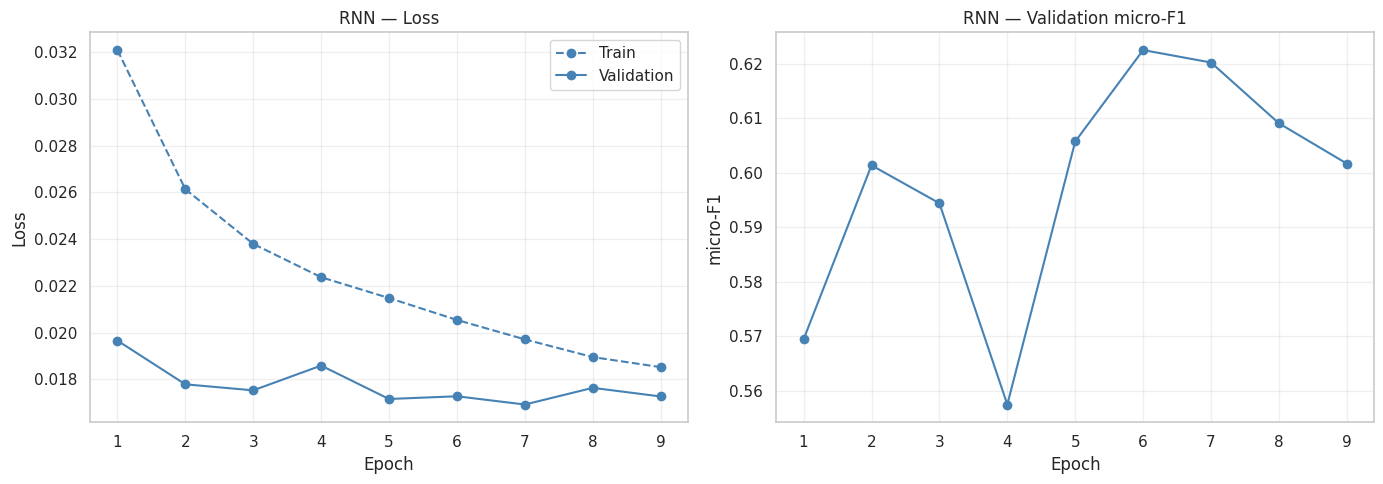

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(rnn_train_losses)+1), rnn_train_losses,
             "o--", color=MODEL_COLORS["RNN"], label="Train")
axes[0].plot(range(1, len(rnn_val_losses)+1), rnn_val_losses,
             "o-",  color=MODEL_COLORS["RNN"], label="Validation")
axes[0].set_title("RNN — Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(rnn_val_f1s)+1), rnn_val_f1s,
             "o-", color=MODEL_COLORS["RNN"])
axes[1].set_title("RNN — Validation micro-F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("micro-F1")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4.5 — RNN Confusion Matrices (per label, gated predictions)

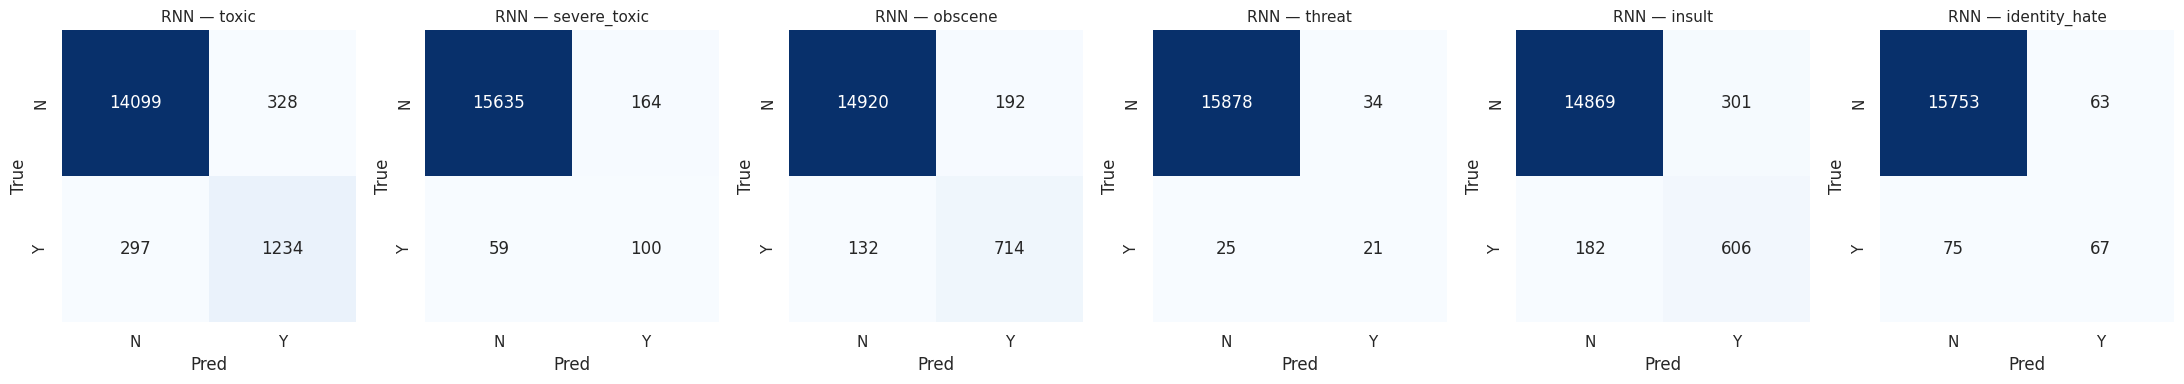

In [27]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, col in enumerate(LABEL_COLS):
    cm = confusion_matrix(rnn_test_labels[:, i], rnn_test_results["y_pred"][:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["N", "Y"], yticklabels=["N", "Y"], ax=axes[i])
    axes[i].set_title(f"RNN — {col}", fontsize=11)
    axes[i].set_xlabel("Pred"); axes[i].set_ylabel("True")
plt.tight_layout(); plt.show()

## 4.6 — RNN ROC & PR Curves
ROC for ranking quality, PR for imbalanced decision quality.

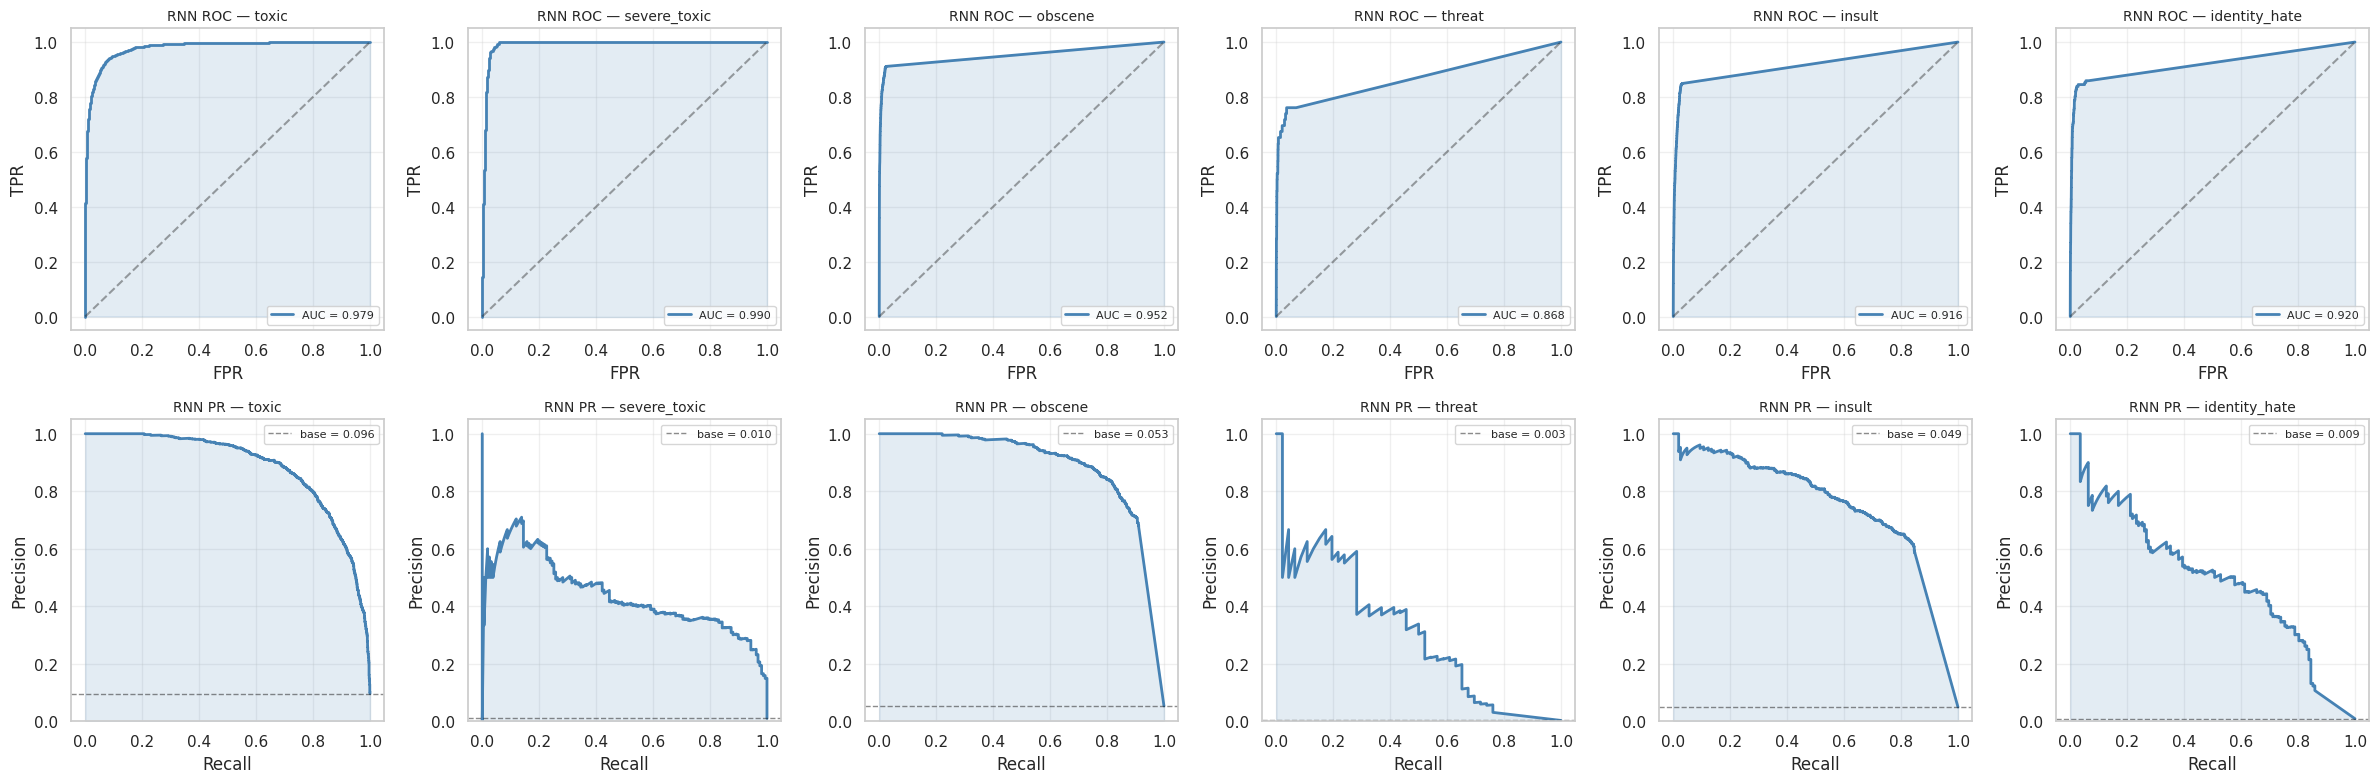

In [28]:
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for i, col in enumerate(LABEL_COLS):
    yt = rnn_test_labels[:, i]
    pr = rnn_test_probs_gated[:, i]

    # ROC
    fpr, tpr, _ = roc_curve(yt, pr)
    auc_val = rnn_test_results["per_class"][col]["auc"]
    axes[0, i].plot(fpr, tpr, color=MODEL_COLORS["RNN"], lw=2, label=f"AUC = {auc_val:.3f}")
    axes[0, i].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[0, i].fill_between(fpr, 0, tpr, color=MODEL_COLORS["RNN"], alpha=0.15)
    axes[0, i].set_title(f"RNN ROC — {col}", fontsize=10)
    axes[0, i].set_xlabel("FPR"); axes[0, i].set_ylabel("TPR")
    axes[0, i].legend(loc="lower right", fontsize=8); axes[0, i].grid(alpha=0.3)

    # PR
    p, r, _ = precision_recall_curve(yt, pr)
    base = yt.mean()
    axes[1, i].plot(r, p, color=MODEL_COLORS["RNN"], lw=2)
    axes[1, i].axhline(base, color="k", ls="--", lw=1, alpha=0.5, label=f"base = {base:.3f}")
    axes[1, i].fill_between(r, 0, p, color=MODEL_COLORS["RNN"], alpha=0.15)
    axes[1, i].set_title(f"RNN PR — {col}", fontsize=10)
    axes[1, i].set_xlabel("Recall"); axes[1, i].set_ylabel("Precision")
    axes[1, i].legend(loc="best", fontsize=8)
    axes[1, i].grid(alpha=0.3); axes[1, i].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

## 4.7 — RNN Summary Metrics

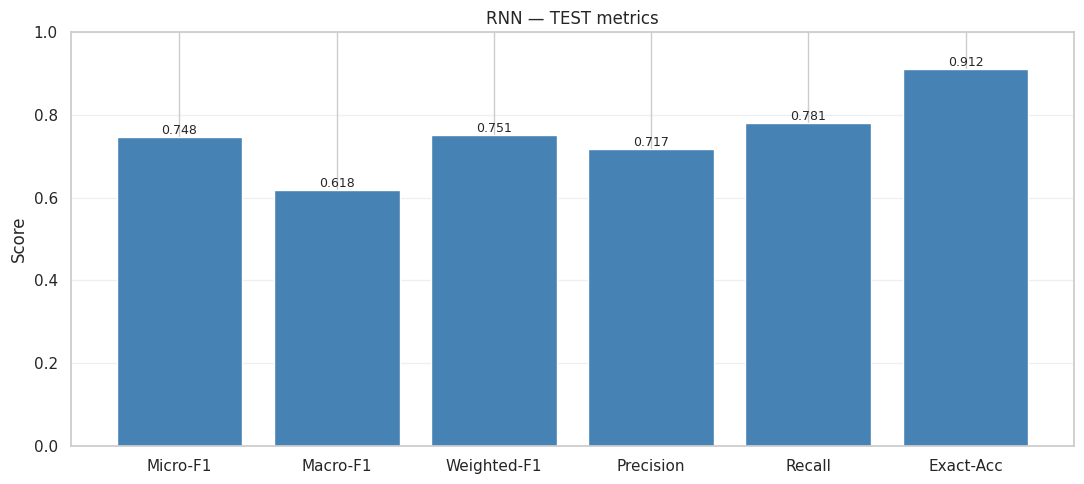

RNN Macro-AUC = 0.9376


In [29]:
keys = ["f1_micro", "f1_macro", "f1_weighted", "precision_micro", "recall_micro", "accuracy_exact"]
labels = ["Micro-F1", "Macro-F1", "Weighted-F1", "Precision", "Recall", "Exact-Acc"]
vals = [rnn_test_results[k] for k in keys]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, vals, color=MODEL_COLORS["RNN"])
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("RNN — TEST metrics")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"RNN Macro-AUC = {rnn_test_results['auc_macro']:.4f}")

# Section 5 — LSTM Pipeline

Stacked BiLSTM with the same three-pooled head as the RNN.
Mirrors Section 4 exactly so the two can be compared cleanly in Section 6.

## 5.1 — LSTM Architecture

In [30]:
class ToxicLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,
                 num_layers=2, dropout=0.4, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
        self.embed_dropout = nn.Dropout(0.15)

        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        feat = hidden_dim * 2

        self.attention = nn.Sequential(
            nn.Linear(feat, feat // 2), nn.Tanh(), nn.Linear(feat // 2, 1)
        )
        self.layer_norm = nn.LayerNorm(feat * 3)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(feat * 3, feat), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(feat, output_dim)
        )

    def forward(self, x, lengths):
        emb = self.embed_dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        out, _ = pad_packed_sequence(self.lstm(packed)[0],
                                     batch_first=True, total_length=x.size(1))
        mask = (x != 0).unsqueeze(-1)

        scores  = self.attention(out).masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        attn_ctx = (out * weights).sum(dim=1)
        max_ctx  = out.masked_fill(~mask, -1e9).max(dim=1).values
        mean_ctx = (out * mask.float()).sum(dim=1) / lengths.float().clamp(min=1).unsqueeze(1)

        ctx = self.layer_norm(torch.cat([attn_ctx, max_ctx, mean_ctx], dim=1))
        return self.classifier(self.dropout(ctx))

## 5.2 — LSTM Training

In [31]:
print("=" * 60)
print("Training LSTM (Stacked BiLSTM, GloVe-300d, focal loss)")
print("=" * 60)

set_seed()
lstm_model = ToxicLSTM(
    vocab_size=vocab.vocab_size, embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS, dropout=DROPOUT,
    embedding_matrix=embedding_matrix,
).to(device)

lstm_params = [
    {"params": lstm_model.embedding.parameters(), "lr": EMBED_LR, "weight_decay": 0.0},
    {"params": [p for n, p in lstm_model.named_parameters() if not n.startswith("embedding")],
     "lr": BASE_LR, "weight_decay": WEIGHT_DECAY},
]

lstm_criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, pos_weight=pos_weight_tensor)
lstm_opt       = torch.optim.AdamW(lstm_params)
lstm_sched     = torch.optim.lr_scheduler.CosineAnnealingLR(
    lstm_opt, T_max=EPOCHS * len(train_loader), eta_min=1e-5
)

(lstm_train_losses, lstm_val_losses, lstm_val_f1s,
 lstm_val_logits, lstm_val_probs, lstm_val_labels) = train_model(
    lstm_model, train_loader, val_loader,
    lstm_criterion, lstm_opt, lstm_sched,
    epochs=EPOCHS, patience=PATIENCE,
    device=device, model_name="LSTM",
)

Training LSTM (Stacked BiLSTM, GloVe-300d, focal loss)
[LSTM] E01/10 | TrL 0.0309 | VlL 0.0199 | val_macroF1@0.5 0.5583
[LSTM] E02/10 | TrL 0.0235 | VlL 0.0180 | val_macroF1@0.5 0.5812
[LSTM] E03/10 | TrL 0.0214 | VlL 0.0170 | val_macroF1@0.5 0.5972
[LSTM] E04/10 | TrL 0.0197 | VlL 0.0164 | val_macroF1@0.5 0.6144
[LSTM] E05/10 | TrL 0.0184 | VlL 0.0160 | val_macroF1@0.5 0.6355
[LSTM] E06/10 | TrL 0.0175 | VlL 0.0166 | val_macroF1@0.5 0.6264
[LSTM] E07/10 | TrL 0.0164 | VlL 0.0187 | val_macroF1@0.5 0.6217
[LSTM] E08/10 | TrL 0.0156 | VlL 0.0183 | val_macroF1@0.5 0.6305
[LSTM] Early stopping. Best val macro-F1 = 0.6355


## 5.3 — LSTM Validation Report

In [32]:
# --- Fit Platt on CALIB, tune thresholds on VAL ---
lstm_calib_logits, _, lstm_calib_labels = _forward_probs(lstm_model, calib_loader, device)
lstm_val_probs_calib = calibrate_probs(lstm_calib_logits, lstm_calib_labels, lstm_val_logits)
lstm_thresholds  = tune_thresholds_macro(lstm_val_labels, lstm_val_probs_calib)
lstm_t_toxic     = tune_gating_threshold_macro(lstm_val_labels, lstm_val_probs_calib, lstm_thresholds)
print(f"[LSTM] val thresholds = {[round(t,3) for t in lstm_thresholds]}  | t_toxic = {lstm_t_toxic:.3f}")

# --- Apply the SAME Platt fit to TEST ---
lstm_test_logits, _, lstm_test_labels = _forward_probs(lstm_model, test_loader, device)
lstm_test_probs = calibrate_probs(lstm_calib_logits, lstm_calib_labels, lstm_test_logits)
lstm_test_probs_gated = apply_hierarchical_gating(lstm_test_probs, lstm_t_toxic)
lstm_test_results = evaluate_model(
    lstm_test_labels, lstm_test_probs_gated, lstm_thresholds,
    "LSTM — TEST (calibrated + gated, macro-F1 tuned)"
)

[LSTM] val thresholds = [0.4, 0.25, 0.4, 0.2, 0.45, 0.25]  | t_toxic = 0.550

===== LSTM — TEST (calibrated + gated, macro-F1 tuned) =====
Macro-F1    : 0.6368   <-- primary
Micro-F1    : 0.7559
Weighted-F1 : 0.7643
Macro-P/R   : 0.5894 / 0.7179
Exact-Acc   : 0.9163
Macro-AUC   : 0.9571

label                F1    Prec  Recall     AUC     Pos
toxic            0.8100  0.8228  0.7975  0.9822    1531
severe_toxic     0.5056  0.3924  0.7107  0.9913     159
obscene          0.8251  0.8114  0.8392  0.9575     846
threat           0.4219  0.3293  0.5870  0.9371      46
insult           0.7238  0.7294  0.7183  0.9372     788
identity_hate    0.5345  0.4515  0.6549  0.9375     142


## 5.4 — LSTM Training Curves

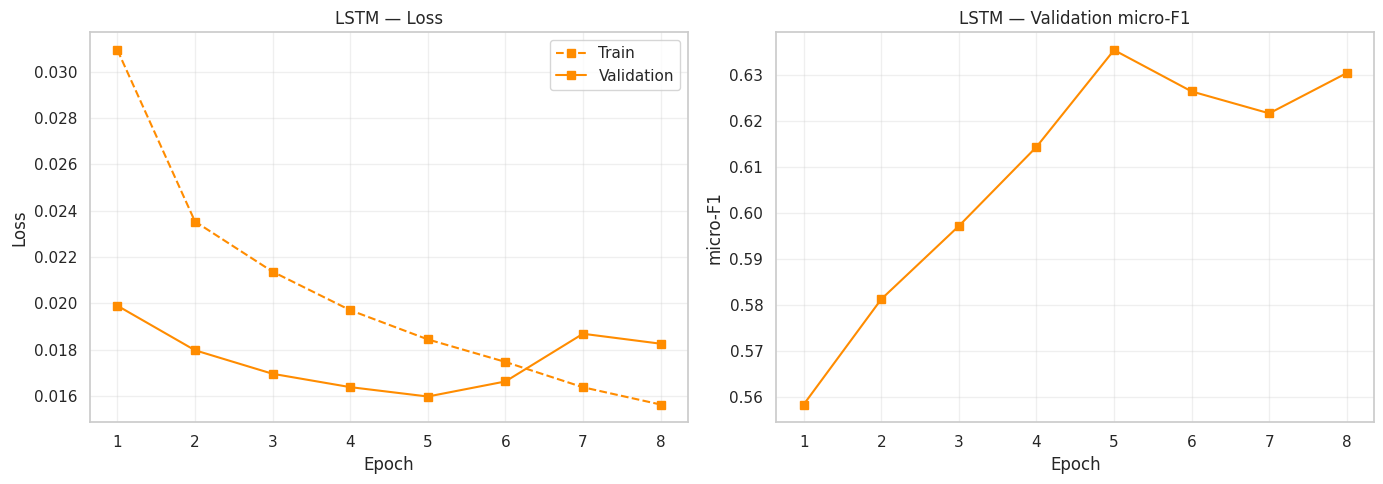

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(lstm_train_losses)+1), lstm_train_losses,
             "s--", color=MODEL_COLORS["LSTM"], label="Train")
axes[0].plot(range(1, len(lstm_val_losses)+1), lstm_val_losses,
             "s-",  color=MODEL_COLORS["LSTM"], label="Validation")
axes[0].set_title("LSTM — Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(lstm_val_f1s)+1), lstm_val_f1s,
             "s-", color=MODEL_COLORS["LSTM"])
axes[1].set_title("LSTM — Validation micro-F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("micro-F1")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5.5 — LSTM Confusion Matrices

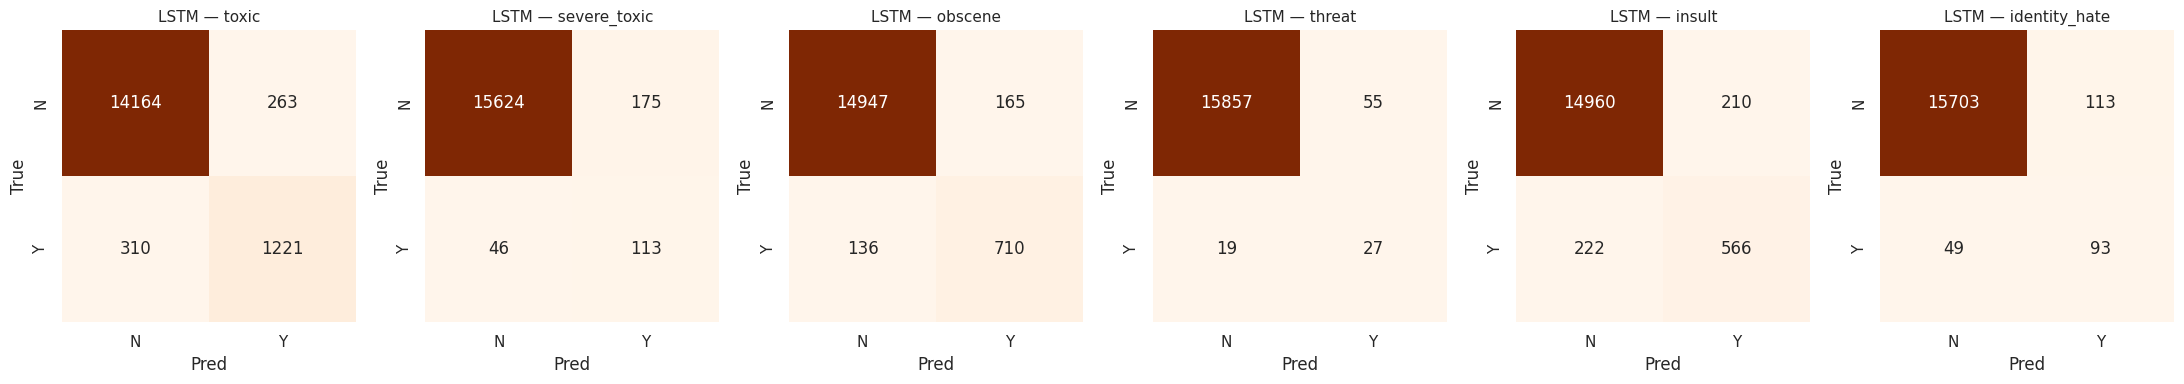

In [34]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, col in enumerate(LABEL_COLS):
    cm = confusion_matrix(lstm_test_labels[:, i], lstm_test_results["y_pred"][:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                xticklabels=["N", "Y"], yticklabels=["N", "Y"], ax=axes[i])
    axes[i].set_title(f"LSTM — {col}", fontsize=11)
    axes[i].set_xlabel("Pred"); axes[i].set_ylabel("True")
plt.tight_layout(); plt.show()

## 5.6 — LSTM ROC & PR Curves

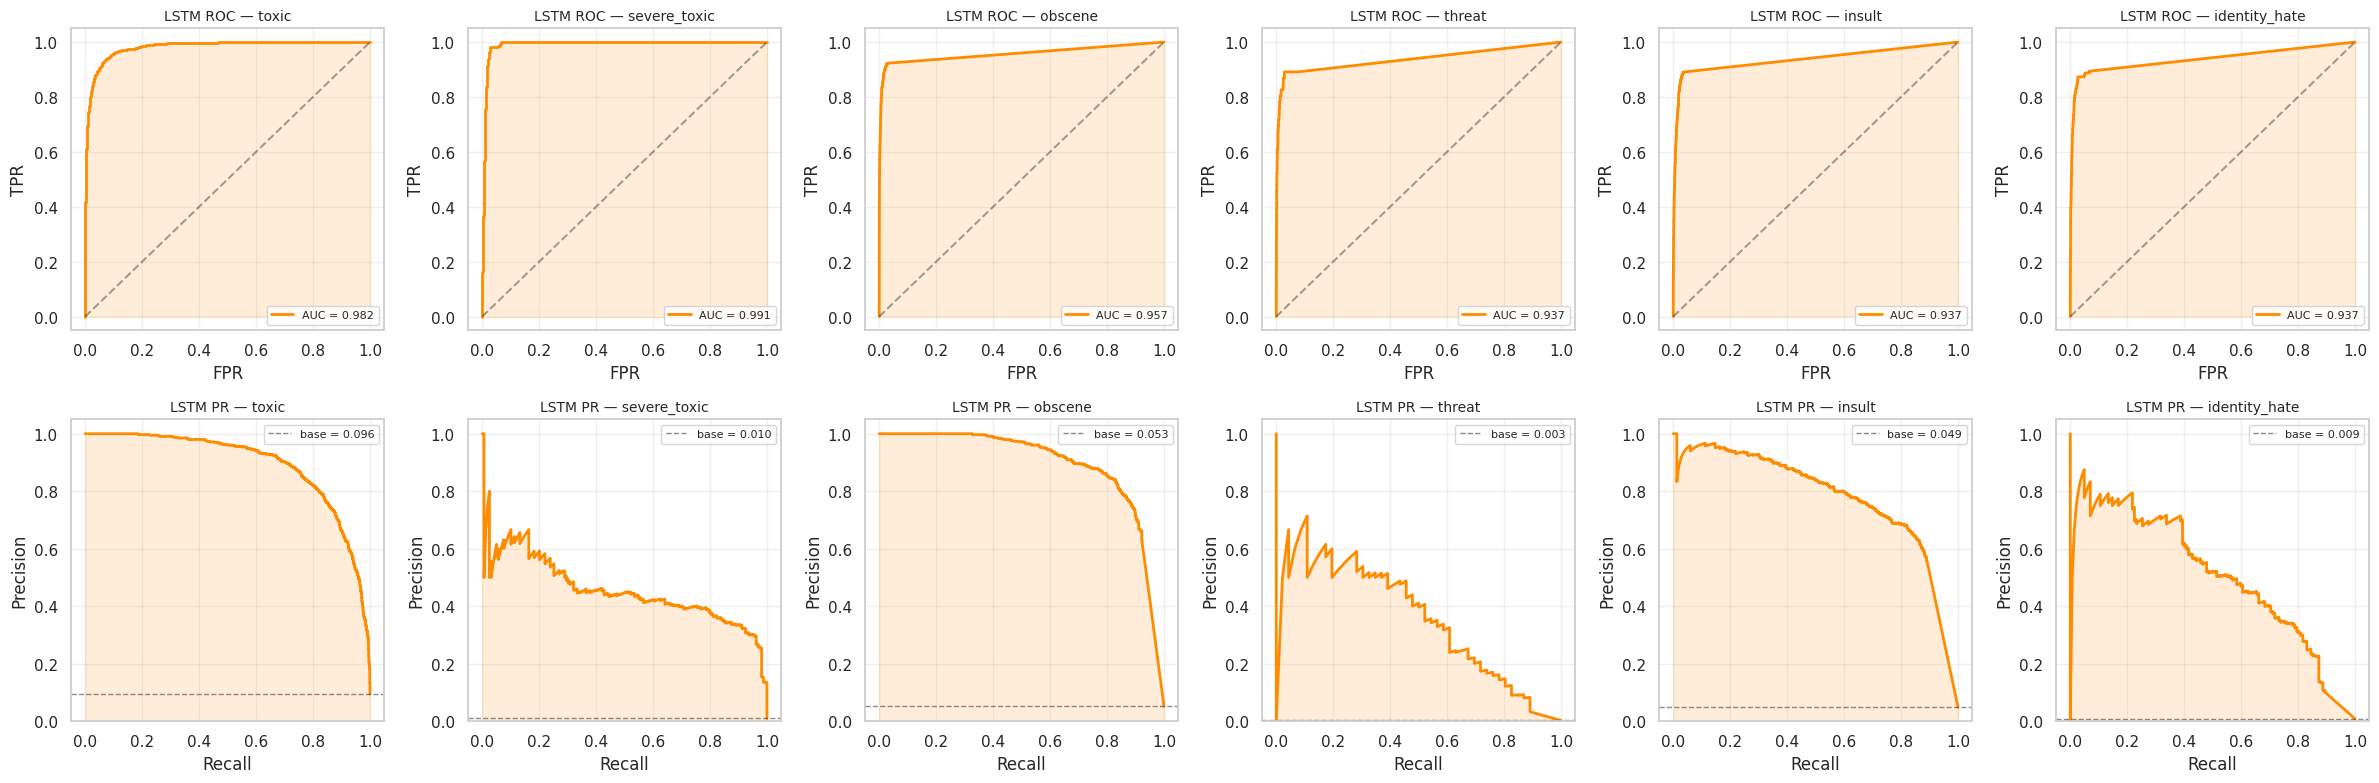

In [35]:
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for i, col in enumerate(LABEL_COLS):
    yt = lstm_test_labels[:, i]
    pr = lstm_test_probs_gated[:, i]

    # ROC
    fpr, tpr, _ = roc_curve(yt, pr)
    auc_val = lstm_test_results["per_class"][col]["auc"]
    axes[0, i].plot(fpr, tpr, color=MODEL_COLORS["LSTM"], lw=2, label=f"AUC = {auc_val:.3f}")
    axes[0, i].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[0, i].fill_between(fpr, 0, tpr, color=MODEL_COLORS["LSTM"], alpha=0.15)
    axes[0, i].set_title(f"LSTM ROC — {col}", fontsize=10)
    axes[0, i].set_xlabel("FPR"); axes[0, i].set_ylabel("TPR")
    axes[0, i].legend(loc="lower right", fontsize=8); axes[0, i].grid(alpha=0.3)

    # PR
    p, r, _ = precision_recall_curve(yt, pr)
    base = yt.mean()
    axes[1, i].plot(r, p, color=MODEL_COLORS["LSTM"], lw=2)
    axes[1, i].axhline(base, color="k", ls="--", lw=1, alpha=0.5, label=f"base = {base:.3f}")
    axes[1, i].fill_between(r, 0, p, color=MODEL_COLORS["LSTM"], alpha=0.15)
    axes[1, i].set_title(f"LSTM PR — {col}", fontsize=10)
    axes[1, i].set_xlabel("Recall"); axes[1, i].set_ylabel("Precision")
    axes[1, i].legend(loc="best", fontsize=8)
    axes[1, i].grid(alpha=0.3); axes[1, i].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

## 5.7 — LSTM Summary Metrics

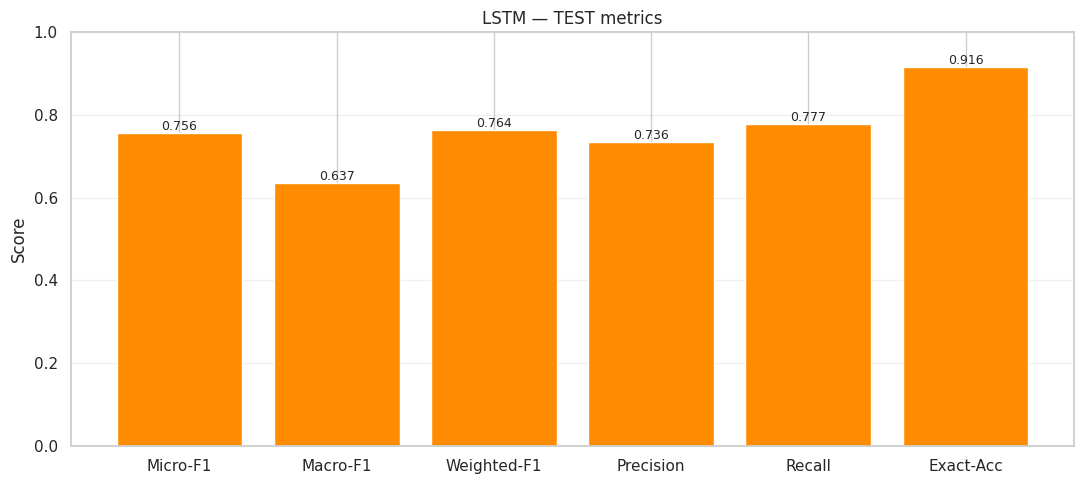

LSTM Macro-AUC = 0.9571


In [36]:
keys = ["f1_micro", "f1_macro", "f1_weighted", "precision_micro", "recall_micro", "accuracy_exact"]
labels = ["Micro-F1", "Macro-F1", "Weighted-F1", "Precision", "Recall", "Exact-Acc"]
vals = [lstm_test_results[k] for k in keys]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, vals, color=MODEL_COLORS["LSTM"])
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("LSTM — TEST metrics")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(f"LSTM Macro-AUC = {lstm_test_results['auc_macro']:.4f}")

# Section 6 — Model Comparison

Side-by-side metrics, per-class F1/AUC heatmaps, and overlaid training curves.
This is the reporting section for the final write-up.

## 6.1 — Overall Metrics (Validation)

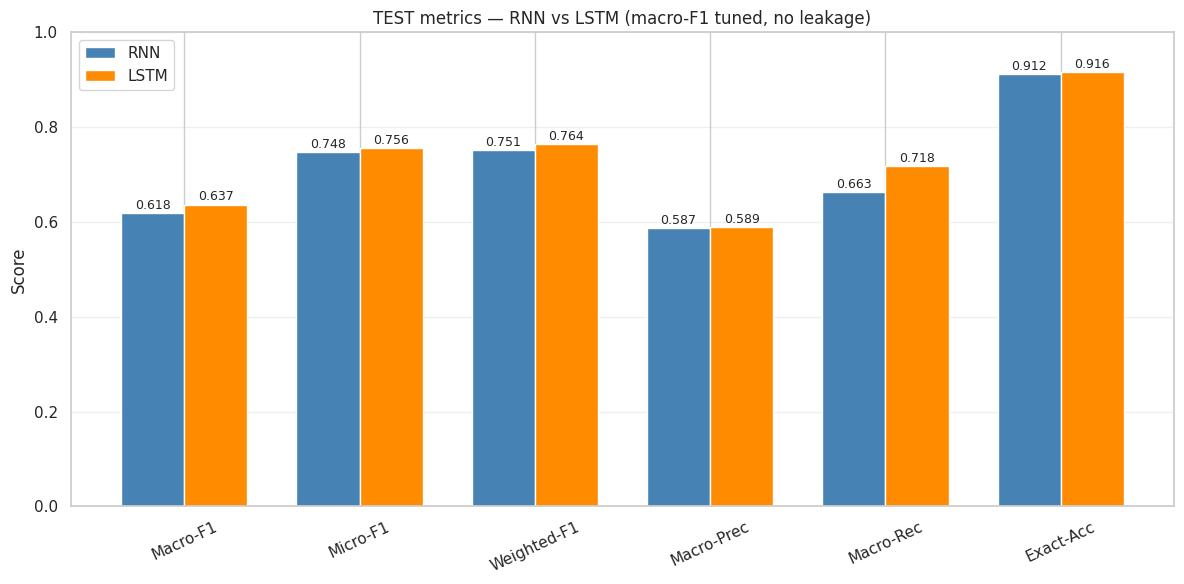

RNN  TEST Macro-AUC = 0.9376
LSTM TEST Macro-AUC = 0.9571


In [37]:
keys   = ["f1_macro", "f1_micro", "f1_weighted",
          "precision_macro", "recall_macro", "accuracy_exact"]
labels = ["Macro-F1", "Micro-F1", "Weighted-F1", "Macro-Prec", "Macro-Rec", "Exact-Acc"]
rnn_vals  = [rnn_test_results[k]  for k in keys]
lstm_vals = [lstm_test_results[k] for k in keys]

x = np.arange(len(keys)); w = 0.36
fig, ax = plt.subplots(figsize=(12, 6))
r1 = ax.bar(x - w/2, rnn_vals,  w, color=MODEL_COLORS["RNN"],  label="RNN")
r2 = ax.bar(x + w/2, lstm_vals, w, color=MODEL_COLORS["LSTM"], label="LSTM")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25)
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("TEST metrics — RNN vs LSTM (macro-F1 tuned, no leakage)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
for bars in (r1, r2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x()+b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"RNN  TEST Macro-AUC = {rnn_test_results['auc_macro']:.4f}")
print(f"LSTM TEST Macro-AUC = {lstm_test_results['auc_macro']:.4f}")

In [38]:
from sklearn.utils import resample

def bootstrap_macro_f1(y_true, y_pred, n=1000, seed=42):
    rng = np.random.RandomState(seed)
    scores = []
    n_rows = len(y_true)
    for _ in range(n):
        idx = rng.randint(0, n_rows, n_rows)
        scores.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    return np.percentile(scores, [2.5, 97.5])

rnn_lo, rnn_hi   = bootstrap_macro_f1(rnn_test_labels,  rnn_test_results["y_pred"])
lstm_lo, lstm_hi = bootstrap_macro_f1(lstm_test_labels, lstm_test_results["y_pred"])
print(f"RNN  macro-F1 95% CI: [{rnn_lo:.3f}, {rnn_hi:.3f}]")
print(f"LSTM macro-F1 95% CI: [{lstm_lo:.3f}, {lstm_hi:.3f}]")

#the RNN and LSTM macro-F1 difference is within bootstrap uncertainty

RNN  macro-F1 95% CI: [0.588, 0.645]
LSTM macro-F1 95% CI: [0.609, 0.661]


## 6.2 — Per-class F1 / AUC Comparison
Heatmap view makes systematic wins/losses obvious at a glance.

,RNN_F1,LSTM_F1,RNN_AUC,LSTM_AUC,F1_delta,AUC_delta
toxic,0.7979,0.8100,0.9793,0.9822,0.0120,0.0029
severe_toxic,0.4728,0.5056,0.9904,0.9913,0.0328,0.0009
obscene,0.8151,0.8251,0.9518,0.9575,0.0100,0.0057
threat,0.4158,0.4219,0.8678,0.9371,0.0060,0.0693
insult,0.7150,0.7238,0.9161,0.9372,0.0087,0.0210
identity_hate,0.4926,0.5345,0.9201,0.9375,0.0418,0.0174


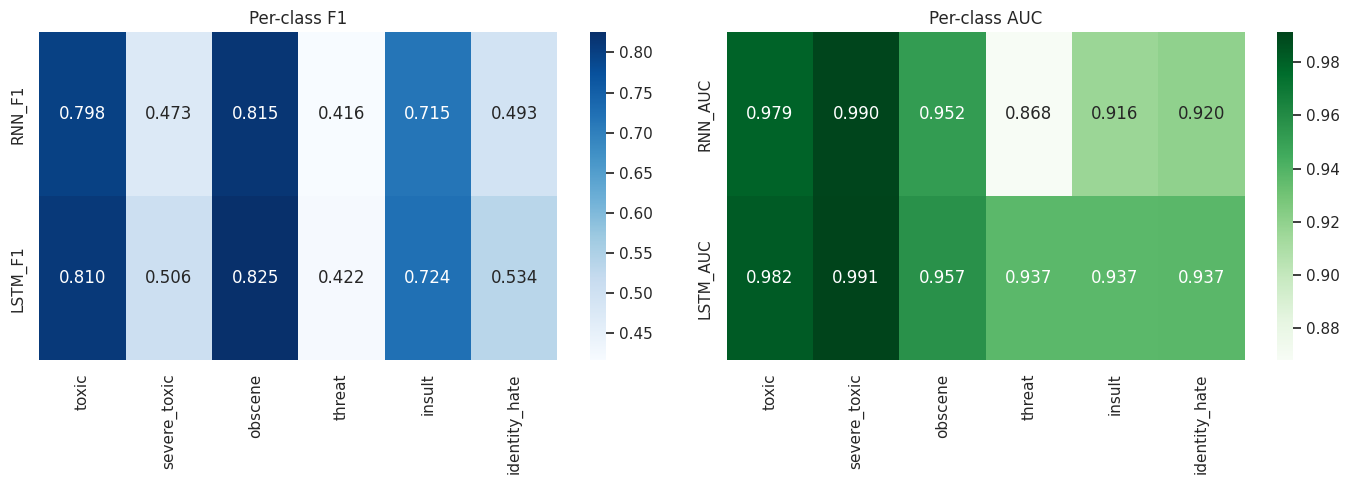

In [39]:
metric_df = pd.DataFrame({
    "RNN_F1":  [rnn_test_results["per_class"][c]["f1"]  for c in LABEL_COLS],
    "LSTM_F1": [lstm_test_results["per_class"][c]["f1"] for c in LABEL_COLS],
    "RNN_AUC": [rnn_test_results["per_class"][c]["auc"]  for c in LABEL_COLS],
    "LSTM_AUC":[lstm_test_results["per_class"][c]["auc"] for c in LABEL_COLS],
}, index=LABEL_COLS)
metric_df["F1_delta"]  = metric_df["LSTM_F1"]  - metric_df["RNN_F1"]
metric_df["AUC_delta"] = metric_df["LSTM_AUC"] - metric_df["RNN_AUC"]
display(metric_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(metric_df[["RNN_F1", "LSTM_F1"]].T, annot=True, fmt=".3f",
            cmap="Blues", ax=axes[0])
axes[0].set_title("Per-class F1")
sns.heatmap(metric_df[["RNN_AUC", "LSTM_AUC"]].T, annot=True, fmt=".3f",
            cmap="Greens", ax=axes[1])
axes[1].set_title("Per-class AUC")
plt.tight_layout(); plt.show()

LSTM wins on macro-F1 (+0.03) but loses on macro-AUC (-0.015). This means LSTM's threshold tuning is doing more work while its underlying ranking is worse. Worth flagging: the RNN's probabilities are better ordered, but its per-class thresholds are further from optimal.

## 6.3 — Training Curves Overlay
Loss and validation micro-F1 for both models on the same axes.

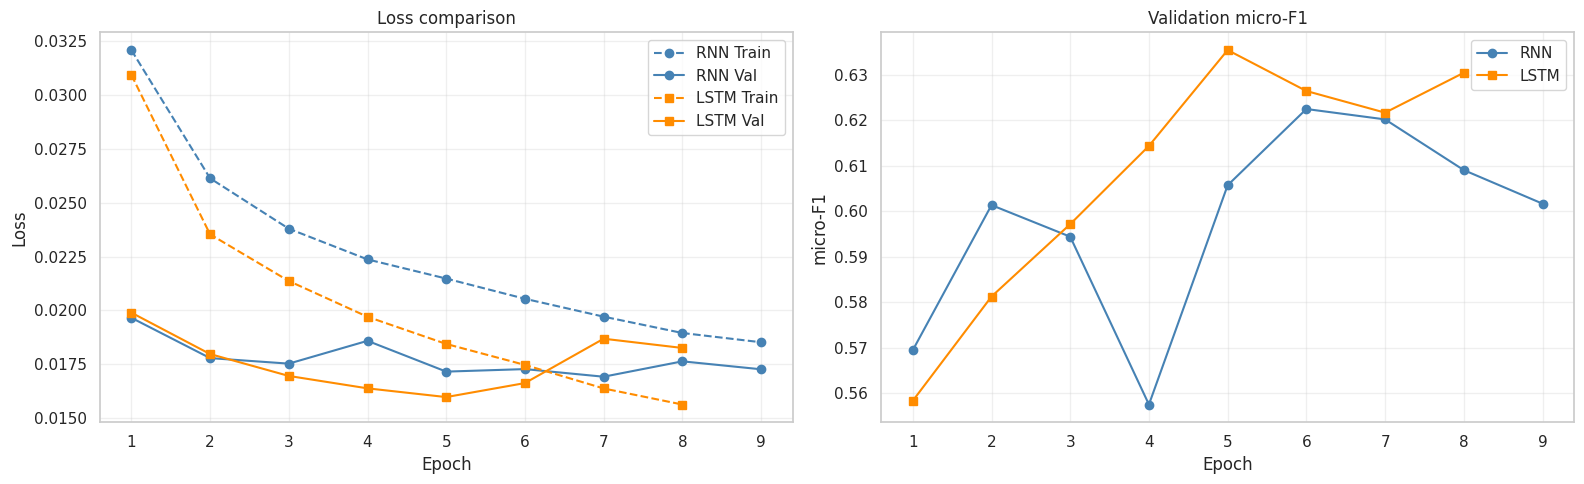

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(1, len(rnn_train_losses)+1),  rnn_train_losses,
             "o--", color=MODEL_COLORS["RNN"],  label="RNN Train")
axes[0].plot(range(1, len(rnn_val_losses)+1),    rnn_val_losses,
             "o-",  color=MODEL_COLORS["RNN"],  label="RNN Val")
axes[0].plot(range(1, len(lstm_train_losses)+1), lstm_train_losses,
             "s--", color=MODEL_COLORS["LSTM"], label="LSTM Train")
axes[0].plot(range(1, len(lstm_val_losses)+1),   lstm_val_losses,
             "s-",  color=MODEL_COLORS["LSTM"], label="LSTM Val")
axes[0].set_title("Loss comparison"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(rnn_val_f1s)+1),  rnn_val_f1s,
             "o-", color=MODEL_COLORS["RNN"],  label="RNN")
axes[1].plot(range(1, len(lstm_val_f1s)+1), lstm_val_f1s,
             "s-", color=MODEL_COLORS["LSTM"], label="LSTM")
axes[1].set_title("Validation micro-F1"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("micro-F1")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Section 7 — Test Evaluation

Uses the calibrated + gated recipe tuned on validation.
No ensembling. No keyword heuristics.

## 7.1 — Test Set Sanity Check
Verify the merge between test text and test labels, and count scored rows.

In [42]:
test_df     = pd.read_csv("test.csv")
test_labels = pd.read_csv("test_labels.csv")

test_merged = test_df.merge(test_labels, on="id", how="left")
test_merged["clean_text"] = test_merged["comment_text"].apply(clean_text)

print("test rows        :", len(test_df))
print("test_labels rows :", len(test_labels))
print("merged rows      :", len(test_merged))
print("duplicate IDs    :", int(test_merged["id"].duplicated().sum()))
print("missing labels   :", test_merged[LABEL_COLS].isnull().sum().to_dict())

for col in LABEL_COLS:
    print(f"  {col:15s} values = {test_merged[col].value_counts(dropna=False).to_dict()}")

# Raw label matrix (kept for masking -1 later)
y_test_raw = test_merged[LABEL_COLS].values.astype(int)

test rows        : 153164
test_labels rows : 153164
merged rows      : 153164
duplicate IDs    : 0
missing labels   : {'toxic': 0, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 0, 'identity_hate': 0}
  toxic           values = {-1: 89186, 0: 57888, 1: 6090}
  severe_toxic    values = {-1: 89186, 0: 63611, 1: 367}
  obscene         values = {-1: 89186, 0: 60287, 1: 3691}
  threat          values = {-1: 89186, 0: 63767, 1: 211}
  insult          values = {-1: 89186, 0: 60551, 1: 3427}
  identity_hate   values = {-1: 89186, 0: 63266, 1: 712}


## 7.2 — Test Dataset & Inference Utilities
No sorting at inference — predictions stay aligned with `y_test_raw`.

In [43]:
class TestDataset(Dataset):
    def __init__(self, texts, vocab, max_len=MAX_LEN):
        self.texts, self.vocab, self.max_len = texts, vocab, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        toks = self.vocab.numericalize(self.texts[i])[:self.max_len] or [1]
        return torch.tensor(toks), torch.tensor(len(toks))

def test_collate_fn(batch):
    # No sorting: pack_padded_sequence uses enforce_sorted=False at inference.
    xs, ls = zip(*batch)
    return pad_sequence(xs, batch_first=True, padding_value=0), torch.stack(ls)

test_texts   = test_merged["clean_text"].tolist()
test_dataset = TestDataset(test_texts, vocab)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=test_collate_fn)

def predict_logits(model, loader, device):
    model.eval()
    out = []
    with torch.no_grad():
        for xb, lens in loader:
            xb, lens = xb.to(device), lens.to(device)
            out.append(model(xb, lens).cpu().numpy())
    return np.vstack(out)

## 7.3 — Test-Time Pipeline
1. Calibrate test logits using the Platt scaler fit on validation.
2. Apply hierarchical gating with the validation-tuned `t_toxic`.
3. Mask rows whose labels contain -1 (unlabeled) during scoring.

In [44]:
def full_test_pipeline(logits_test, logits_val, y_val, t_toxic):
    probs_cal   = calibrate_probs(logits_val, y_val, logits_test)
    probs_gated = apply_hierarchical_gating(probs_cal, t_toxic)
    return probs_gated

def evaluate_test(y_true_raw, y_probs, thresholds, model_name):
    y_true_raw = np.asarray(y_true_raw)
    y_probs    = np.asarray(y_probs)
    valid      = (y_true_raw != -1).all(axis=1)
    n_valid    = int(valid.sum())
    print(f"[{model_name}] scored rows: {n_valid} / {len(y_true_raw)}")
    if n_valid == 0:
        raise ValueError("No valid test rows to score.")
    results = evaluate_model(y_true_raw[valid], y_probs[valid],
                             thresholds, f"{model_name} Test")
    results["n_valid"]    = n_valid
    results["valid_rows"] = valid
    return results

## 7.4 — RNN Test Report

In [45]:
rnn_test_logits = predict_logits(rnn_model, test_loader, device)
rnn_test_probs  = full_test_pipeline(
    logits_test=rnn_test_logits,
    logits_val=rnn_val_logits, y_val=rnn_val_labels,
    t_toxic=rnn_t_toxic,
)
rnn_test_results = evaluate_test(y_test_raw, rnn_test_probs, rnn_thresholds, "RNN")

[RNN] scored rows: 63978 / 153164

===== RNN Test =====
Macro-F1    : 0.5381   <-- primary
Micro-F1    : 0.6063
Weighted-F1 : 0.6101
Macro-P/R   : 0.4308 / 0.7530
Exact-Acc   : 0.8404
Macro-AUC   : 0.9462

label                F1    Prec  Recall     AUC     Pos
toxic            0.6119  0.4630  0.9021  0.9606    6090
severe_toxic     0.3513  0.2332  0.7112  0.9828     367
obscene          0.6415  0.5265  0.8206  0.9423    3691
threat           0.4281  0.3129  0.6777  0.9402     211
insult           0.6189  0.5106  0.7855  0.9222    3427
identity_hate    0.5766  0.5384  0.6208  0.9287     712


### RNN Test Plots

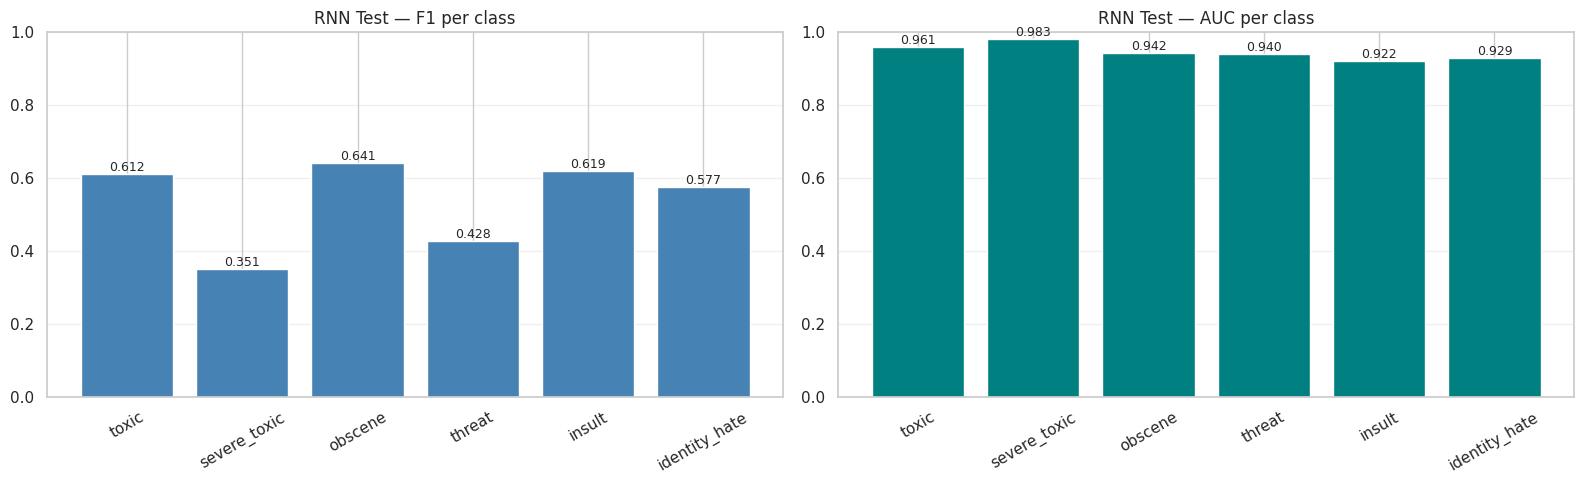

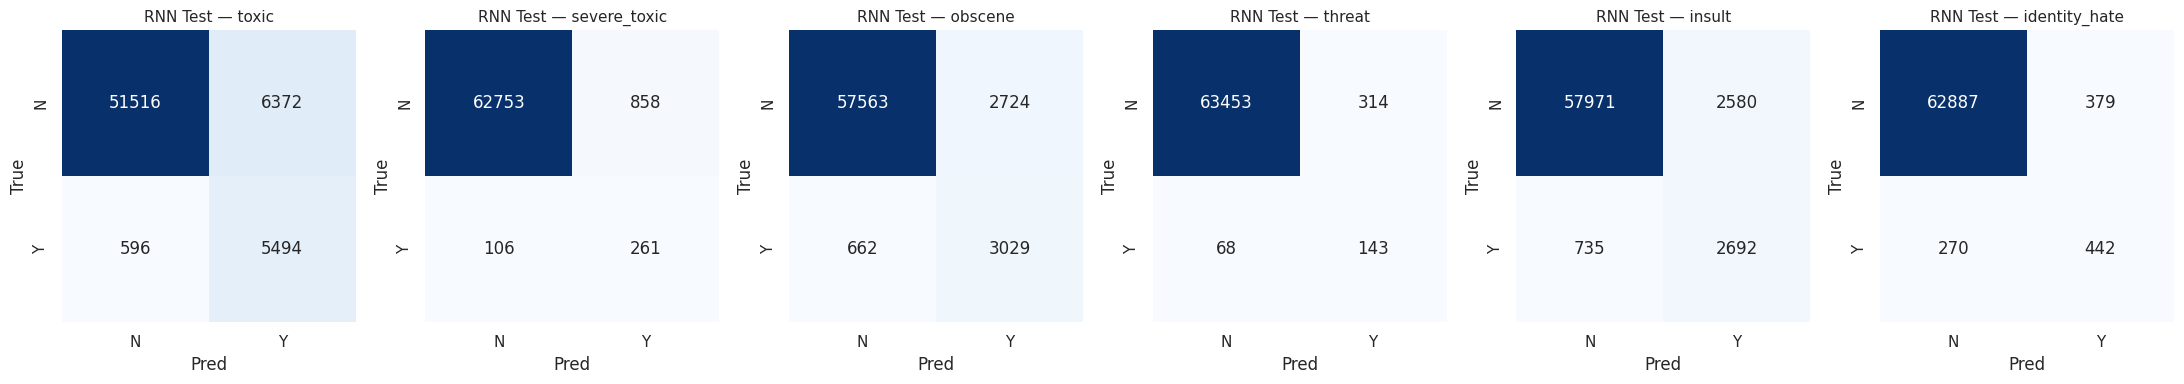

In [46]:
valid = rnn_test_results["valid_rows"]
yt_valid = y_test_raw[valid]
yp_valid = rnn_test_results["y_pred"]

# Per-class F1 bar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
f1s = [rnn_test_results["per_class"][c]["f1"] for c in LABEL_COLS]
aucs= [rnn_test_results["per_class"][c]["auc"] for c in LABEL_COLS]

b = axes[0].bar(LABEL_COLS, f1s, color=MODEL_COLORS["RNN"])
axes[0].set_title("RNN Test — F1 per class"); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30); axes[0].grid(alpha=0.3, axis="y")
for bar, v in zip(b, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

b = axes[1].bar(LABEL_COLS, aucs, color="teal")
axes[1].set_title("RNN Test — AUC per class"); axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30); axes[1].grid(alpha=0.3, axis="y")
for bar, v in zip(b, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

# Confusion matrix grid
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, col in enumerate(LABEL_COLS):
    cm = confusion_matrix(yt_valid[:, i], yp_valid[:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["N", "Y"], yticklabels=["N", "Y"], ax=axes[i])
    axes[i].set_title(f"RNN Test — {col}", fontsize=11)
    axes[i].set_xlabel("Pred"); axes[i].set_ylabel("True")
plt.tight_layout(); plt.show()

## 7.5 — LSTM Test Report

In [47]:
lstm_test_logits = predict_logits(lstm_model, test_loader, device)
lstm_test_probs  = full_test_pipeline(
    logits_test=lstm_test_logits,
    logits_val=lstm_val_logits, y_val=lstm_val_labels,
    t_toxic=lstm_t_toxic,
)
lstm_test_results = evaluate_test(y_test_raw, lstm_test_probs, lstm_thresholds, "LSTM")

[LSTM] scored rows: 63978 / 153164

===== LSTM Test =====
Macro-F1    : 0.5590   <-- primary
Micro-F1    : 0.6436
Weighted-F1 : 0.6496
Macro-P/R   : 0.4544 / 0.7653
Exact-Acc   : 0.8624
Macro-AUC   : 0.9575

label                F1    Prec  Recall     AUC     Pos
toxic            0.6581  0.5228  0.8882  0.9659    6090
severe_toxic     0.3501  0.2390  0.6540  0.9836     367
obscene          0.6796  0.5869  0.8071  0.9443    3691
threat           0.4384  0.3068  0.7678  0.9693     211
insult           0.6651  0.6263  0.7091  0.9339    3427
identity_hate    0.5624  0.4445  0.7654  0.9480     712


### LSTM Test Plots

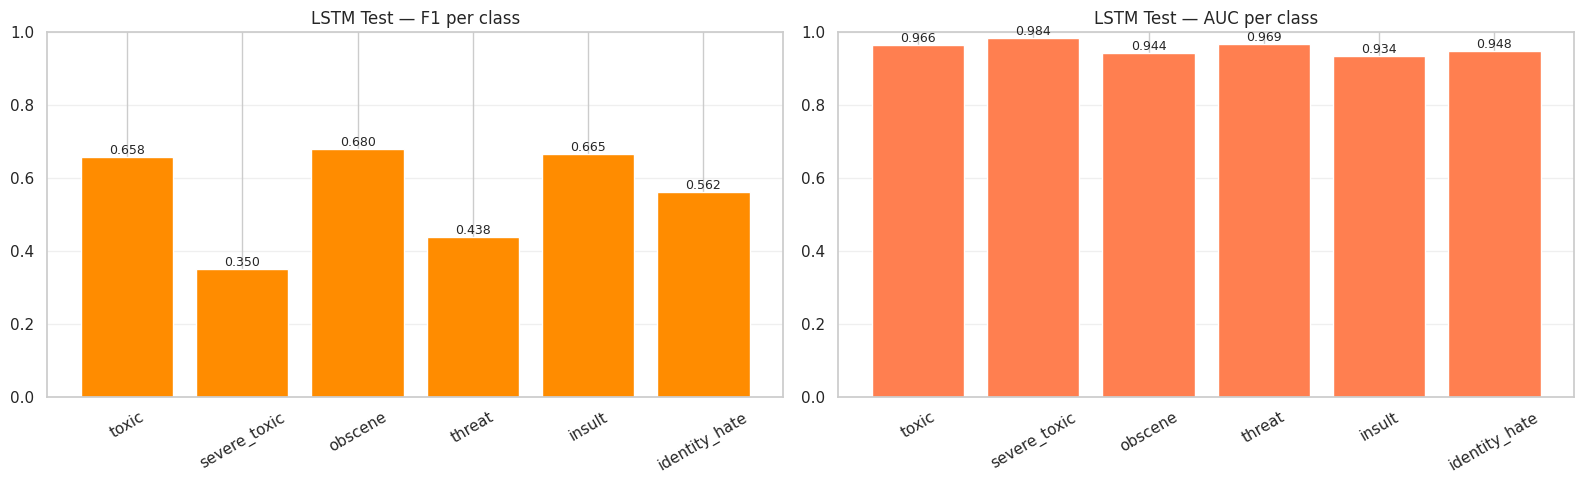

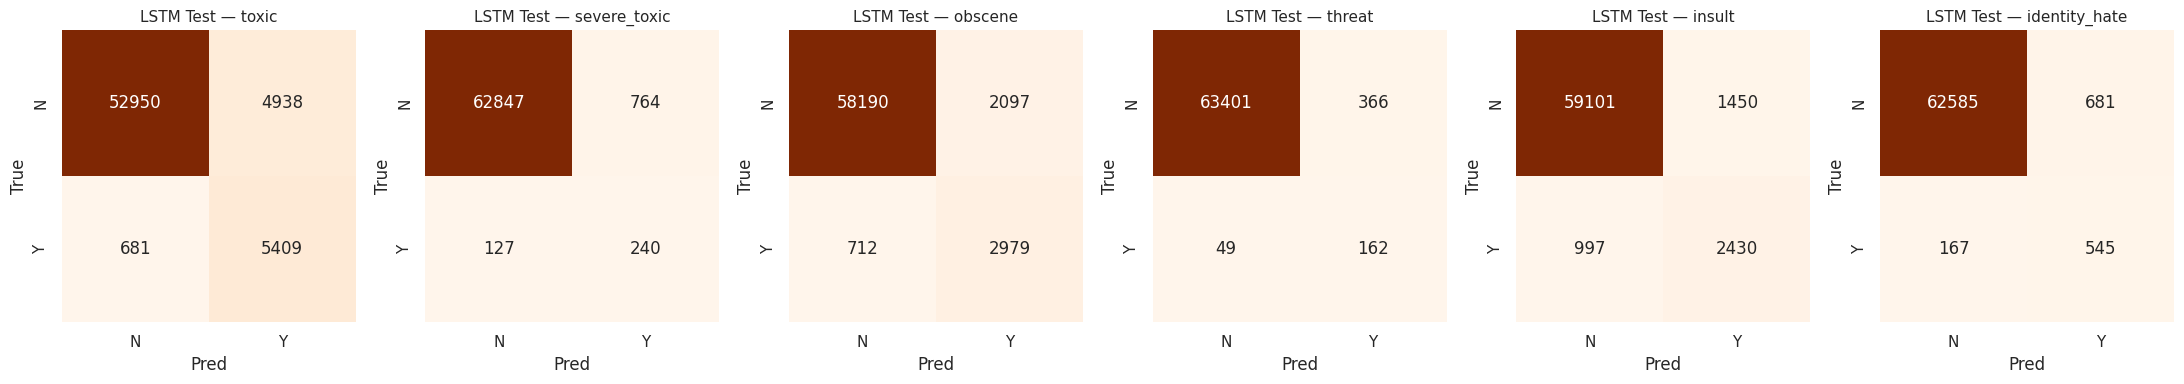

In [48]:
valid = lstm_test_results["valid_rows"]
yt_valid = y_test_raw[valid]
yp_valid = lstm_test_results["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
f1s = [lstm_test_results["per_class"][c]["f1"] for c in LABEL_COLS]
aucs= [lstm_test_results["per_class"][c]["auc"] for c in LABEL_COLS]

b = axes[0].bar(LABEL_COLS, f1s, color=MODEL_COLORS["LSTM"])
axes[0].set_title("LSTM Test — F1 per class"); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30); axes[0].grid(alpha=0.3, axis="y")
for bar, v in zip(b, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

b = axes[1].bar(LABEL_COLS, aucs, color="coral")
axes[1].set_title("LSTM Test — AUC per class"); axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30); axes[1].grid(alpha=0.3, axis="y")
for bar, v in zip(b, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, col in enumerate(LABEL_COLS):
    cm = confusion_matrix(yt_valid[:, i], yp_valid[:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                xticklabels=["N", "Y"], yticklabels=["N", "Y"], ax=axes[i])
    axes[i].set_title(f"LSTM Test — {col}", fontsize=11)
    axes[i].set_xlabel("Pred"); axes[i].set_ylabel("True")
plt.tight_layout(); plt.show()

## 7.6 — Final Test Comparison (RNN vs LSTM)
The single summary table + chart for the report.

,RNN,LSTM,Winner
Micro-F1,0.6063,0.6436,LSTM
Macro-F1,0.5381,0.5590,LSTM
Weighted-F1,0.6101,0.6496,LSTM
Precision,0.4769,0.5333,LSTM
Recall,0.8319,0.8115,RNN
Exact-Acc,0.8404,0.8624,LSTM


RNN  Macro-AUC (test) = 0.9462
LSTM Macro-AUC (test) = 0.9575


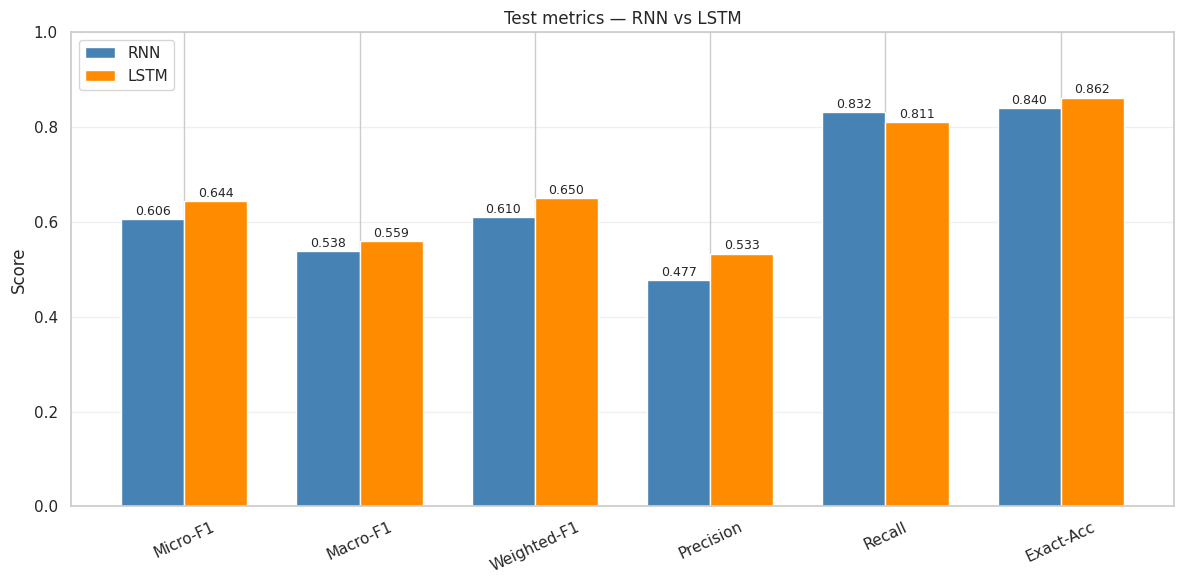

In [49]:
keys   = ["f1_micro", "f1_macro", "f1_weighted", "precision_micro", "recall_micro", "accuracy_exact"]
labels = ["Micro-F1", "Macro-F1", "Weighted-F1", "Precision", "Recall", "Exact-Acc"]
rnn_vals  = [rnn_test_results[k]  for k in keys]
lstm_vals = [lstm_test_results[k] for k in keys]

summary = pd.DataFrame({
    "RNN":  rnn_vals,
    "LSTM": lstm_vals,
}, index=labels).round(4)
summary["Winner"] = np.where(summary["RNN"] > summary["LSTM"], "RNN", "LSTM")
display(summary)

print(f"RNN  Macro-AUC (test) = {rnn_test_results['auc_macro']:.4f}")
print(f"LSTM Macro-AUC (test) = {lstm_test_results['auc_macro']:.4f}")

x = np.arange(len(keys)); w = 0.36
fig, ax = plt.subplots(figsize=(12, 6))
r1 = ax.bar(x - w/2, rnn_vals,  w, color=MODEL_COLORS["RNN"],  label="RNN")
r2 = ax.bar(x + w/2, lstm_vals, w, color=MODEL_COLORS["LSTM"], label="LSTM")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25)
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("Test metrics — RNN vs LSTM")
ax.legend(); ax.grid(alpha=0.3, axis="y")
for bars in (r1, r2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x()+b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### Per-class comparison (heatmap)

,RNN_F1,LSTM_F1,RNN_AUC,LSTM_AUC
toxic,0.6119,0.6581,0.9606,0.9659
severe_toxic,0.3513,0.3501,0.9828,0.9836
obscene,0.6415,0.6796,0.9423,0.9443
threat,0.4281,0.4384,0.9402,0.9693
insult,0.6189,0.6651,0.9222,0.9339
identity_hate,0.5766,0.5624,0.9287,0.9480


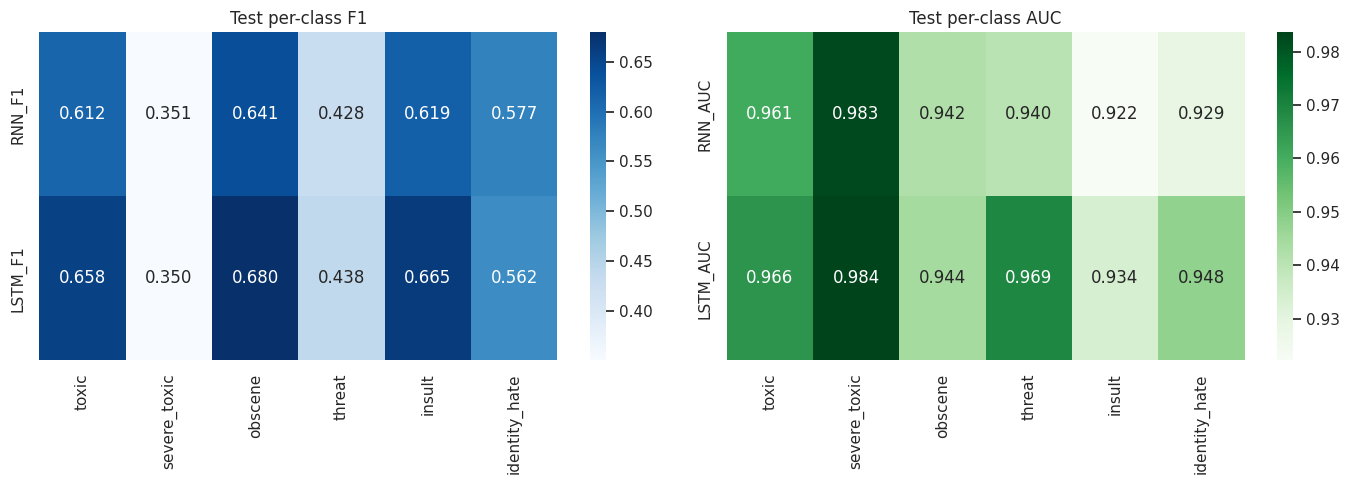

In [50]:
per_class = pd.DataFrame({
    "RNN_F1":   [rnn_test_results["per_class"][c]["f1"]  for c in LABEL_COLS],
    "LSTM_F1":  [lstm_test_results["per_class"][c]["f1"] for c in LABEL_COLS],
    "RNN_AUC":  [rnn_test_results["per_class"][c]["auc"] for c in LABEL_COLS],
    "LSTM_AUC": [lstm_test_results["per_class"][c]["auc"] for c in LABEL_COLS],
}, index=LABEL_COLS).round(4)
display(per_class)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(per_class[["RNN_F1", "LSTM_F1"]].T, annot=True, fmt=".3f",
            cmap="Blues", ax=axes[0]); axes[0].set_title("Test per-class F1")
sns.heatmap(per_class[["RNN_AUC", "LSTM_AUC"]].T, annot=True, fmt=".3f",
            cmap="Greens", ax=axes[1]); axes[1].set_title("Test per-class AUC")
plt.tight_layout(); plt.show()